In [52]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import math

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.optim import Adam, ClippedAdam
from pyro.infer.autoguide import AutoMultivariateNormal, AutoDiagonalNormal

# MBML Final Project

*Model-based Machine Learning, Spring 2026*

*names*

# 1. Motivation

Goal
Dataset

# 2. Exploratory Data Analysis

Basic EDA here

In [2]:
df_original=pd.read_csv("data/train.csv")
df_original.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


In [3]:
df_original = df_original.rename(columns={"DEP_DEL15": "DELAY", "AWND":"WIND"})

print("Missing values per column:")
print(df_original.isnull().sum())

Missing values per column:
MONTH                            0
DAY_OF_WEEK                      0
DELAY                            0
DEP_TIME_BLK                     0
DISTANCE_GROUP                   0
SEGMENT_NUMBER                   0
CONCURRENT_FLIGHTS               0
NUMBER_OF_SEATS                  0
CARRIER_NAME                     0
AIRPORT_FLIGHTS_MONTH            0
AIRLINE_FLIGHTS_MONTH            0
AIRLINE_AIRPORT_FLIGHTS_MONTH    0
AVG_MONTHLY_PASS_AIRPORT         0
AVG_MONTHLY_PASS_AIRLINE         0
FLT_ATTENDANTS_PER_PASS          0
GROUND_SERV_PER_PASS             0
PLANE_AGE                        0
DEPARTING_AIRPORT                0
LATITUDE                         0
LONGITUDE                        0
PREVIOUS_AIRPORT                 0
PRCP                             0
SNOW                             0
SNWD                             0
TMAX                             0
WIND                             0
CARRIER_HISTORICAL               0
DEP_AIRPORT_HIST            

Compute correlations between non categorical variables and delay (target)

               variable  correlation
0         DEP_BLOCK_ENC       0.1672
1        SEGMENT_NUMBER       0.1173
2                  PRCP       0.0801
3                  WIND       0.0509
8        DISTANCE_GROUP       0.0160
7       NUMBER_OF_SEATS       0.0117
4    CONCURRENT_FLIGHTS       0.0094
6             PLANE_AGE       0.0063
5  GROUND_SERV_PER_PASS      -0.0166


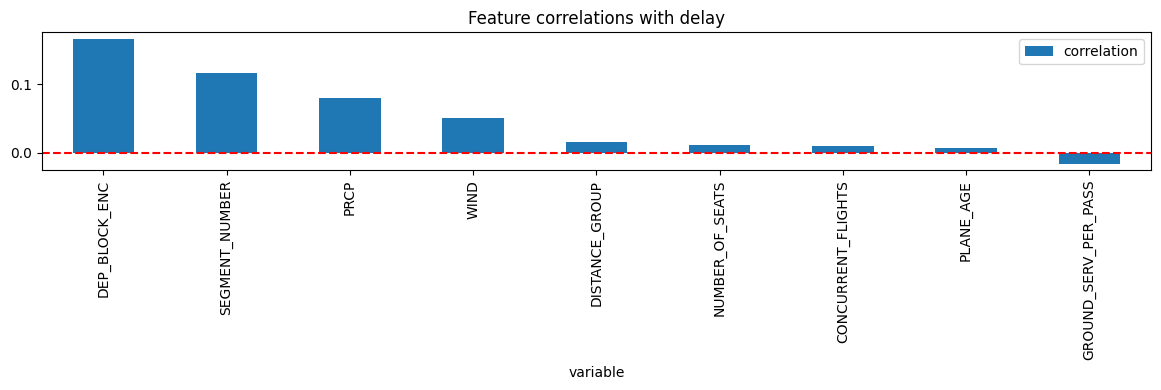

In [4]:
df_original["DEP_BLOCK_ENC"] = pd.Categorical(df_original["DEP_TIME_BLK"]).codes

cols_to_check = [
    "DEP_BLOCK_ENC",
    "SEGMENT_NUMBER", 
    "PRCP",
    "WIND",
    "CONCURRENT_FLIGHTS",
    "GROUND_SERV_PER_PASS",
    "PLANE_AGE",
    "NUMBER_OF_SEATS",
    "DISTANCE_GROUP",
]

results = []
for col in cols_to_check:
    corr = df_original["DELAY"].corr(df_original[col])
    results.append({"variable": col, "correlation": round(corr, 4)})

results_df = pd.DataFrame(results).sort_values("correlation", ascending=False)
print(results_df)

results_df.plot(x="variable", y="correlation", kind="bar", figsize=(12, 4))
plt.axhline(0, color="red", linestyle="--")
plt.title("Feature correlations with delay")
plt.tight_layout()
plt.show()

The most correlated to delay are Departure Block, Segment Number, Rain, Previous Airport Delay Rate and Wind.

Plot the mean delay value for each carrier, to see if it varies between carriers.

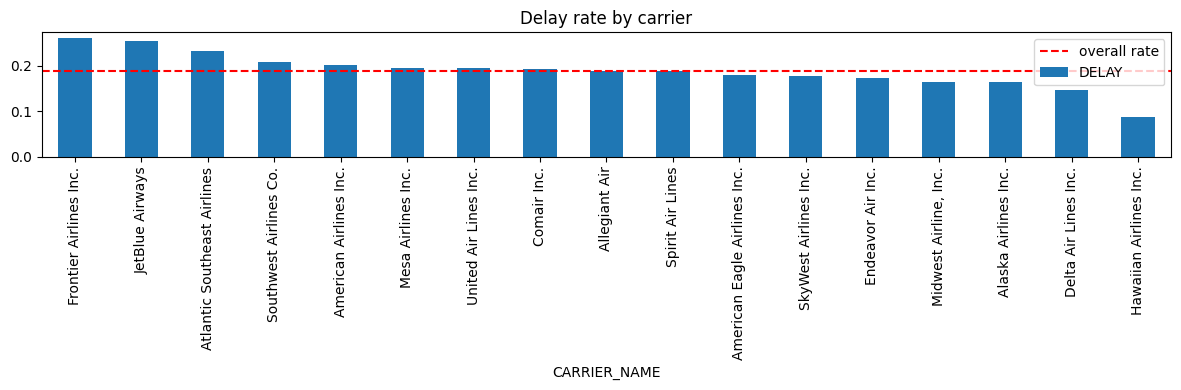

In [5]:
df_original.groupby("CARRIER_NAME")["DELAY"].mean().sort_values(ascending=False).plot(kind="bar", figsize=(12,4))
plt.axhline(df_original["DELAY"].mean(), color="red", linestyle="--", label="overall rate")
plt.title("Delay rate by carrier")
plt.legend()
plt.tight_layout()
plt.show()

There is a clear difference between the top mean delayed carrier and the low mean delayed carrier, so we can consider carrier as have some influence on delay

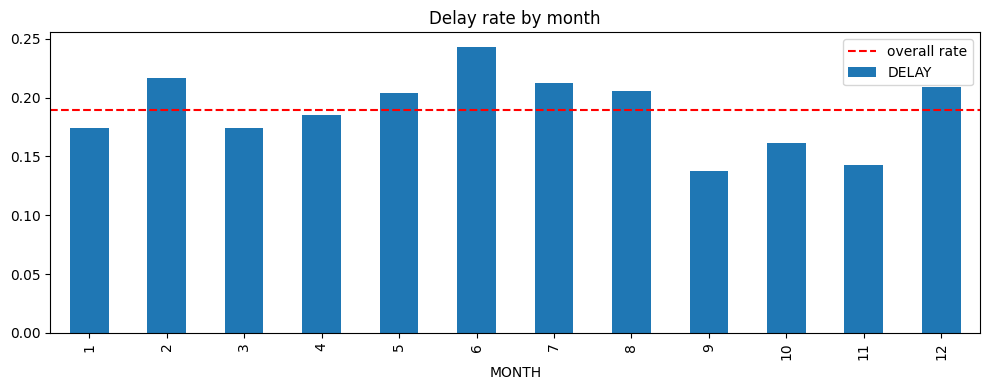

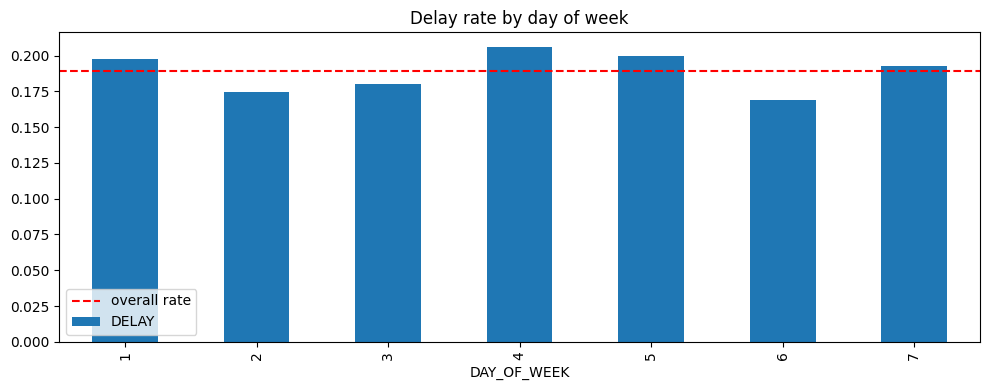

In [6]:
df_original.groupby("MONTH")["DELAY"].mean().sort_index().plot(kind="bar", figsize=(10,4))
plt.axhline(df_original["DELAY"].mean(), color="red", linestyle="--", label="overall rate")
plt.title("Delay rate by month")
plt.legend()
plt.tight_layout()
plt.show()

df_original.groupby("DAY_OF_WEEK")["DELAY"].mean().sort_index().plot(kind="bar", figsize=(10,4))
plt.axhline(df_original["DELAY"].mean(), color="red", linestyle="--", label="overall rate")
plt.title("Delay rate by day of week")
plt.legend()
plt.tight_layout()
plt.show()

The delay rate clearly varies per month but not per day of week.

In [7]:
# compute delay rate per airport from departing airport values
airport_delay_rate = df_original.groupby("DEPARTING_AIRPORT")["DELAY"].mean()
global_median = airport_delay_rate.median()

# map to each flight
df_original["DEPARTING_AIRPORT_DELAY_RATE"] = df_original["DEPARTING_AIRPORT"].map(airport_delay_rate)
df_original["PREV_AIRPORT_DELAY_RATE"] = df_original["PREVIOUS_AIRPORT"].map(airport_delay_rate)

print("Missing values:")
print(f"DEPARTING_AIRPORT_DELAY_RATE: {df_original['DEPARTING_AIRPORT_DELAY_RATE'].isnull().sum()}")
print(f"PREV_AIRPORT_DELAY_RATE: {df_original['PREV_AIRPORT_DELAY_RATE'].isnull().sum()}")

Missing values:
DEPARTING_AIRPORT_DELAY_RATE: 0
PREV_AIRPORT_DELAY_RATE: 1426830


In [8]:
# fill NaN with median
df_original["PREV_AIRPORT_DELAY_RATE"] = df_original["PREV_AIRPORT_DELAY_RATE"].fillna(global_median)

print("\nCorrelations with delay:")
print(f"DEPARTING_AIRPORT_DELAY_RATE: {df_original['DELAY'].corr(df_original['DEPARTING_AIRPORT_DELAY_RATE'])}")
print(f"PREV_AIRPORT_DELAY_RATE: {df_original['DELAY'].corr(df_original['PREV_AIRPORT_DELAY_RATE'])}")


Correlations with delay:
DEPARTING_AIRPORT_DELAY_RATE: 0.08262602003609969
PREV_AIRPORT_DELAY_RATE: 0.07953060781648875


The departing and previous airport delay rates also have some correlation with the delay

So we will keep the variables
 - departure block
 - segment number
 - rain
 - wind
 - month
 - carrier
 - delay rate of departing airport
 - delay rate of previous airport

Now we will check for collinearity between these variables

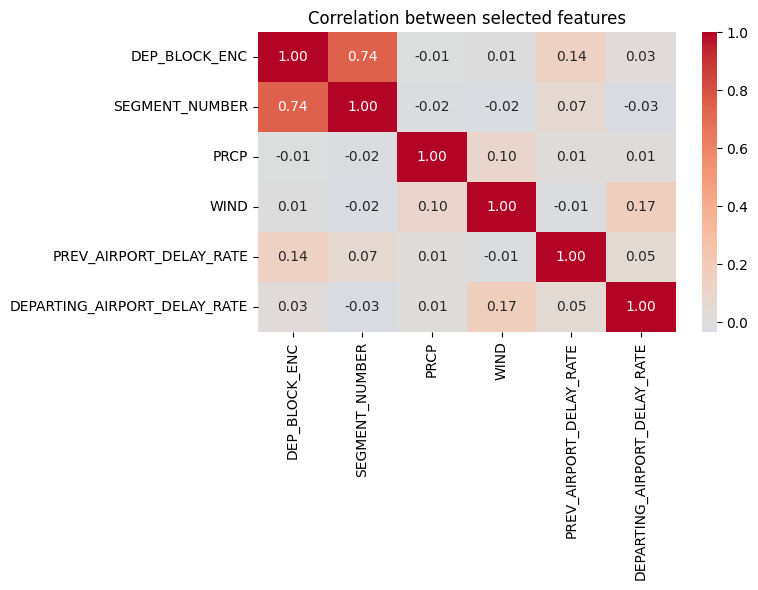

In [9]:
cols_selected = [
    "DEP_BLOCK_ENC",
    "SEGMENT_NUMBER",
    "PRCP",
    "WIND",
    "PREV_AIRPORT_DELAY_RATE",
    "DEPARTING_AIRPORT_DELAY_RATE",
]

corr_matrix = df_original[cols_selected].corr().round(3)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.title("Correlation between selected features")
plt.tight_layout()
plt.show()

We will drop segment number bc it seems to encode the same info as departure block, and departure block has higher correlation with delay. 

Now we will look at month

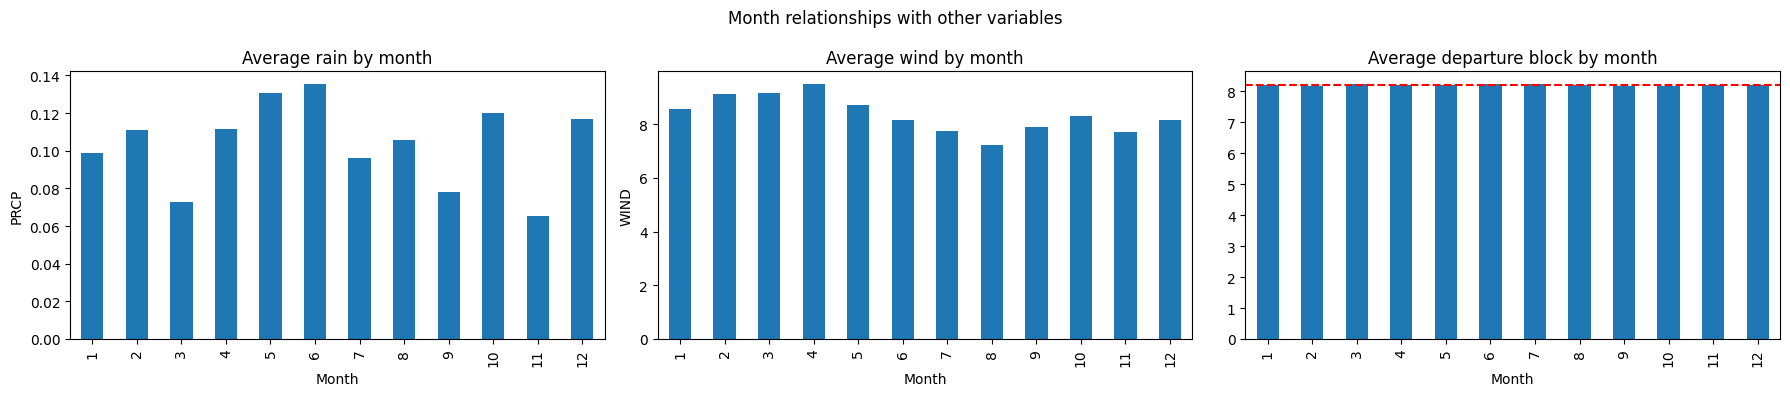

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# month vs rain
df_original.groupby("MONTH")["PRCP"].mean().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Average rain by month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("PRCP")

# month vs wind
df_original.groupby("MONTH")["WIND"].mean().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Average wind by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("WIND")

# month vs departure block distribution
df_original.groupby("MONTH")["DEP_BLOCK_ENC"].mean().sort_index().plot(kind="bar", ax=axes[2])
axes[2].axhline(df_original["DEP_BLOCK_ENC"].mean(), color="red", linestyle="--")
axes[2].set_title("Average departure block by month")
axes[2].set_xlabel("Month")

plt.suptitle("Month relationships with other variables")
plt.tight_layout()
plt.show()

Wind does not vary that much per month, rain varies per month so we will keep both but keeping this in mind, departure block does not vary with month they are independent

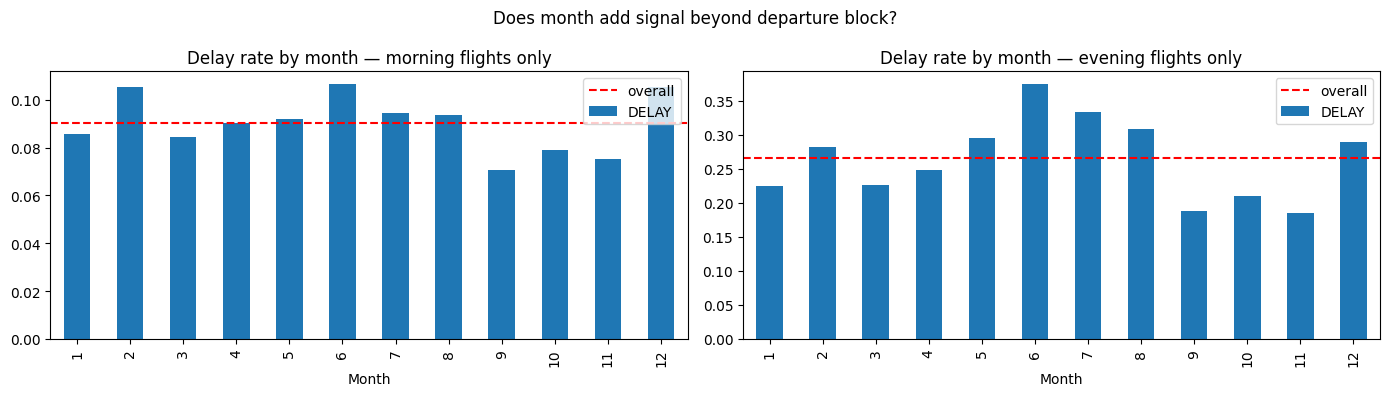

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# morning flights
morning = df_original[df_original["DEP_BLOCK_ENC"] <= 3]
morning.groupby("MONTH")["DELAY"].mean().sort_index().plot(kind="bar", ax=axes[0])
axes[0].axhline(morning["DELAY"].mean(), color="red", linestyle="--", label="overall")
axes[0].set_title("Delay rate by month — morning flights only")
axes[0].set_xlabel("Month")
axes[0].legend()

# evening flights
evening = df_original[df_original["DEP_BLOCK_ENC"] >= 14]
evening.groupby("MONTH")["DELAY"].mean().sort_index().plot(kind="bar", ax=axes[1])
axes[1].axhline(evening["DELAY"].mean(), color="red", linestyle="--", label="overall")
axes[1].set_title("Delay rate by month — evening flights only")
axes[1].set_xlabel("Month")
axes[1].legend()

plt.suptitle("Does month add signal beyond departure block?")
plt.tight_layout()
plt.show()

The pattern is the same regardless of time of the day so month clearly has some signal beyond departure block   

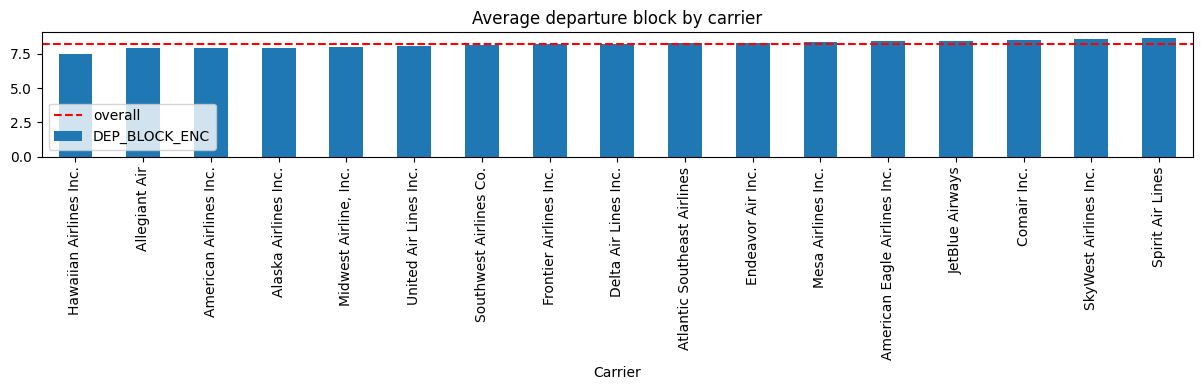

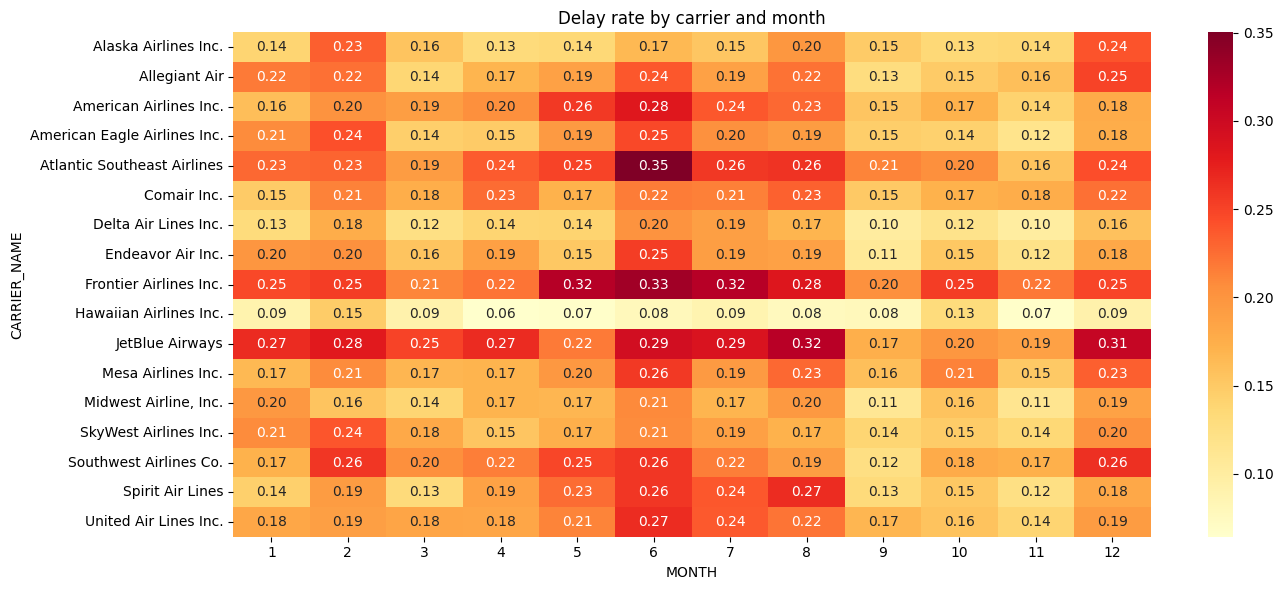

In [12]:
# carrier vs average dept block
fig, ax = plt.subplots(figsize=(12, 4))
df_original.groupby("CARRIER_NAME")["DEP_BLOCK_ENC"].mean().sort_values().plot(kind="bar", ax=ax)
ax.axhline(df_original["DEP_BLOCK_ENC"].mean(), color="red", linestyle="--", label="overall")
ax.set_title("Average departure block by carrier")
ax.set_xlabel("Carrier")
ax.legend()
plt.tight_layout()
plt.show()

# carrier delay rate by month 
fig, ax = plt.subplots(figsize=(14, 6))
carrier_month = df_original.groupby(["CARRIER_NAME", "MONTH"])["DELAY"].mean().unstack()
sns.heatmap(carrier_month, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
ax.set_title("Delay rate by carrier and month")
plt.tight_layout()
plt.show()

In [13]:
# range of delay rates across months per carrier
carrier_month_range = carrier_month.max(axis=1) - carrier_month.min(axis=1)
print("Range of delay rates across months per carrier:")
print(carrier_month_range.sort_values(ascending=False))

Range of delay rates across months per carrier:
CARRIER_NAME
Atlantic Southeast Airlines     0.193315
Endeavor Air Inc.               0.145458
Spirit Air Lines                0.141932
JetBlue Airways                 0.141905
American Airlines Inc.          0.140213
Southwest Airlines Co.          0.139209
American Eagle Airlines Inc.    0.129402
Frontier Airlines Inc.          0.127370
United Air Lines Inc.           0.125395
Allegiant Air                   0.122078
Alaska Airlines Inc.            0.108379
Mesa Airlines Inc.              0.106755
SkyWest Airlines Inc.           0.102871
Delta Air Lines Inc.            0.099848
Midwest Airline, Inc.           0.097663
Comair Inc.                     0.083965
Hawaiian Airlines Inc.          0.083554
dtype: float64


So all carriers have the same average departure block meaning some dont operate more in some times of days than others, carrier and departure block are independent

While month has a global effect on all carriers, the magnitude varies. Atlantic Southeast seasonal range is 0.19 while Hawaiian is 0.08. This suggests a carrier-month interaction.

So 
- rain
- wind
- dept block
- month <br>
into delay <br>

- carrier baseline
- previous airport delay rate
- departing airport delay rate <br>
into stress


*Formal explanation*


The EDA analysis guided the separation of variables into direct delay effects and stress components.

**Direct delay features** <br>
When we plotted delay rate by **precipitation** level we observed a clear monotonic relationship — flights with no rain delayed at 17% while flights with heavy rain delayed at 32%. This confirmed that rain has a direct physical effect on delay regardless of any other conditions, so it goes directly into the delay equation.

**Wind** showed a similar pattern — very low wind flights delayed at 17% while very high wind flights delayed at 22%. The effect is weaker than rain but consistent and statistically significant, justifying its inclusion as a direct delay feature.

For **departure block** we ran a specific test — we looked at delay rates on days with no rain and low wind, asking whether the temporal pattern persisted even when weather was not a factor. The results were striking — even on clear weather days, 6am flights delayed at only 6% while 7pm flights delayed at 22%. This proved that departure block captures something beyond weather — the accumulated fatigue of a system that has been absorbing disruptions all day. Since this effect is direct and universal, departure block goes into the delay equation rather than stress.

For **month** we asked the same question — does the seasonal pattern persist when controlling for departure block? We compared morning and evening flights separately across months and found that June had higher delays than September at every time of day. We also showed that the average departure block is identical across all months — there is no confounding between month and time of day. This confirmed that month captures genuine seasonal signal — summer thunderstorms, winter holidays, demand patterns — independent of departure block and weather.


**Stress features** <br>
For **carrier** we plotted delay rates by carrier and departure block jointly. Two findings stood out. First, all carriers have virtually identical average departure blocks — Frontier does not fly more evening flights than Delta, so its higher delay rate cannot be explained by time of day. Second, looking at the delay rate by carrier and departure block table, Frontier delayed at 16% even at 6am while Delta delayed at only 5% — a 3x difference at the exact same time of day. This proved carrier identity has an independent effect on operational performance beyond time and weather, making it a genuine driver of operational stress rather than a direct delay cause.

For **airports** we computed delay rates per airport and found a 23 percentage point range between the most delayed airport (Puerto Rico International at 31%) and the least delayed (Keahole at 8%). Since airports vary dramatically in their structural delay propensity — due to congestion, layout, ATC complexity — the departing airport delay rate captures the baseline operational pressure of the system this flight is departing from. For previous airport, we computed a proxy using the delay rate of the previous airport and confirmed a positive relationship with delay — flights coming from high-delay airports are more likely to delay themselves, capturing cascading operational pressure from upstream.


The fundamental distinction is causal — rain delays a flight because of physics, while carrier operational culture and airport congestion delay a flight because the system lacks the slack to absorb disruptions. Departure block and month are direct temporal and seasonal effects on the whole system, while carrier and airport characteristics determine how fragile the operational system is when disruptions occur. This causal reasoning directly motivated the model structure — direct effects in the delay equation, operational fragility captured through the latent stress variable.


# 2. Download datasets

## Train

In [14]:
df_train = df_original[["DELAY", "CARRIER_NAME", "PRCP", "WIND", "MONTH", "DEP_TIME_BLK", "DEP_BLOCK_ENC", "PREV_AIRPORT_DELAY_RATE", "DEPARTING_AIRPORT_DELAY_RATE"]]
print(f"Number of observations: {len(df_train)}")
print(df_train.isna().sum())
df_train.head()

Number of observations: 4542343
DELAY                           0
CARRIER_NAME                    0
PRCP                            0
WIND                            0
MONTH                           0
DEP_TIME_BLK                    0
DEP_BLOCK_ENC                   0
PREV_AIRPORT_DELAY_RATE         0
DEPARTING_AIRPORT_DELAY_RATE    0
dtype: int64


,DELAY,CARRIER_NAME,PRCP,WIND,MONTH,DEP_TIME_BLK,DEP_BLOCK_ENC,PREV_AIRPORT_DELAY_RATE,DEPARTING_AIRPORT_DELAY_RATE
0,0,American Airlines Inc.,0.00,4.25,7,1500-1559,10,0.224594,0.195292
1,0,SkyWest Airlines Inc.,0.00,11.41,4,1300-1359,8,0.159366,0.225547
2,0,American Eagle Airlines Inc.,0.00,0.45,11,0001-0559,0,0.170699,0.163854
3,0,Southwest Airlines Co.,0.00,8.05,3,1500-1559,10,0.147617,0.172137
4,0,American Eagle Airlines Inc.,0.01,10.51,7,0800-0859,3,0.181550,0.224594


One hot encode month, carrier and departure time block
- January as reference
- Spirit Air Lines as reference (closest to the overall delay rate)
- 0001-0559 as reference

In [15]:
carrier_delay = df_original.groupby("CARRIER_NAME")["DELAY"].mean()
overall_rate = df_original["DELAY"].mean()

print(f"Overall delay rate: {overall_rate}")
print("\nCarrier delay rates vs overall:")
print((carrier_delay - overall_rate).abs().sort_values())

Overall delay rate: 0.18914423679585624

Carrier delay rates vs overall:
CARRIER_NAME
Spirit Air Lines                0.000590
Allegiant Air                   0.000611
Comair Inc.                     0.004844
United Air Lines Inc.           0.006139
Mesa Airlines Inc.              0.006304
American Eagle Airlines Inc.    0.009451
SkyWest Airlines Inc.           0.010806
American Airlines Inc.          0.011891
Endeavor Air Inc.               0.014819
Southwest Airlines Co.          0.019898
Midwest Airline, Inc.           0.024863
Alaska Airlines Inc.            0.025160
Delta Air Lines Inc.            0.042759
Atlantic Southeast Airlines     0.043935
JetBlue Airways                 0.064829
Frontier Airlines Inc.          0.071501
Hawaiian Airlines Inc.          0.102194
Name: DELAY, dtype: float64


In [16]:
print((carrier_delay - overall_rate).sort_values())

CARRIER_NAME
Hawaiian Airlines Inc.         -0.102194
Delta Air Lines Inc.           -0.042759
Alaska Airlines Inc.           -0.025160
Midwest Airline, Inc.          -0.024863
Endeavor Air Inc.              -0.014819
SkyWest Airlines Inc.          -0.010806
American Eagle Airlines Inc.   -0.009451
Spirit Air Lines               -0.000590
Allegiant Air                   0.000611
Comair Inc.                     0.004844
United Air Lines Inc.           0.006139
Mesa Airlines Inc.              0.006304
American Airlines Inc.          0.011891
Southwest Airlines Co.          0.019898
Atlantic Southeast Airlines     0.043935
JetBlue Airways                 0.064829
Frontier Airlines Inc.          0.071501
Name: DELAY, dtype: float64


In [17]:
month_delay = df_original.groupby("MONTH")["DELAY"].mean()
overall_rate = df_original["DELAY"].mean()

print(f"Overall delay rate: {overall_rate}")
print("\nMonth delay rates vs overall:")
print((month_delay - overall_rate).abs().sort_values())

Overall delay rate: 0.18914423679585624

Month delay rates vs overall:
MONTH
4     0.004262
1     0.014586
5     0.014739
3     0.014762
8     0.016762
12    0.019886
7     0.023316
10    0.027590
2     0.027896
11    0.046547
9     0.051262
6     0.054176
Name: DELAY, dtype: float64


In [18]:
month_dummies = pd.get_dummies(df_train["MONTH"], prefix="month")
month_columns = month_dummies.columns.tolist()
# drop April as reference
month_columns_model = month_columns[:]   
month_columns_model.pop(3)               

carrier_dummies = pd.get_dummies(df_train["CARRIER_NAME"], prefix="carrier")
carrier_columns = carrier_dummies.columns.tolist()
carrier_columns_model = [c for c in carrier_columns if "Spirit" not in c]

dpt_dummies = pd.get_dummies(df_train["DEP_TIME_BLK"], prefix="dep_block")
dpt_columns = dpt_dummies.columns.tolist()
# drops 0001-0559 as reference
dpt_columns_model = dpt_columns[1:]

df_train = pd.concat([df_train,carrier_dummies[carrier_columns_model],dpt_dummies[dpt_columns_model],month_dummies[month_columns_model]], axis=1)

Encode carrier as an integer index

In [19]:
carrier_categories = df_train["CARRIER_NAME"].astype("category").cat.categories
df_train["CARRIER_IDX"] = pd.Categorical(df_train["CARRIER_NAME"], categories=carrier_categories).codes

## Train sample

In [20]:
df_train["STRAT_KEY"] = (df_train["DELAY"].astype(str) + "_" + df_train["CARRIER_NAME"])

df_sample, _ = train_test_split(df_train, train_size=0.1, stratify=df_train["STRAT_KEY"], random_state=42)
df_sample = df_sample.drop(columns=["STRAT_KEY"])
df_train  = df_train.drop(columns=["STRAT_KEY"])

print(df_sample.shape)

(454234, 55)


In [21]:
print("Delay rate")
print(f"Full: {df_train['DELAY'].mean()}")
print(f"Sample: {df_sample['DELAY'].mean()}")

print("\nCarrier distribution")
print(pd.DataFrame({"full": df_train["CARRIER_NAME"].value_counts(normalize=True), "sample": df_sample["CARRIER_NAME"].value_counts(normalize=True)}))

print("\nMonth distribution")
print(pd.DataFrame({"full": df_train["MONTH"].value_counts(normalize=True).sort_index(), "sample": df_sample["MONTH"].value_counts(normalize=True).sort_index()}))

print("\nDeparture block distribution")
print(pd.DataFrame({"full":   df_train["DEP_TIME_BLK"].value_counts(normalize=True).sort_index(), "sample": df_sample["DEP_TIME_BLK"].value_counts(normalize=True).sort_index()}))

print("\nContinuous variables")
for col in ["PRCP", "WIND", "PREV_AIRPORT_DELAY_RATE", "DEPARTING_AIRPORT_DELAY_RATE"]:
    if col in df_train.columns:
        print(f"\n{col}:")
        print(f"full: mean: {df_train[col].mean()}, std: {df_train[col].std()}")
        print(f"sample: mean: {df_sample[col].mean()}, std: {df_sample[col].std()}")

print("\nMissing carriers or departure blocks")
print("Carriers in full not in sample:", set(df_train["CARRIER_NAME"].unique()) - set(df_sample["CARRIER_NAME"].unique()))
print("Months in full not in sample:", set(df_train["MONTH"].unique()) - set(df_sample["MONTH"].unique()))
print("Dep blocks in full not in sample:", set(df_train["DEP_TIME_BLK"].unique()) - set(df_sample["DEP_TIME_BLK"].unique()))

Delay rate
Full: 0.18914423679585624
Sample: 0.18914480201834297

Carrier distribution
                                  full    sample
CARRIER_NAME                                    
Southwest Airlines Co.        0.199693  0.199694
Delta Air Lines Inc.          0.144653  0.144652
American Airlines Inc.        0.139305  0.139305
United Air Lines Inc.         0.092601  0.092600
SkyWest Airlines Inc.         0.090069  0.090068
Midwest Airline, Inc.         0.046297  0.046298
JetBlue Airways               0.041477  0.041476
Alaska Airlines Inc.          0.036896  0.036895
American Eagle Airlines Inc.  0.035310  0.035310
Comair Inc.                   0.033763  0.033762
Endeavor Air Inc.             0.031371  0.031371
Spirit Air Lines              0.029209  0.029210
Mesa Airlines Inc.            0.027336  0.027336
Frontier Airlines Inc.        0.018706  0.018706
Atlantic Southeast Airlines   0.015226  0.015226
Hawaiian Airlines Inc.        0.011546  0.011547
Allegiant Air                 0

### Weather data

In [27]:
weather_scaler = StandardScaler()
df_sample["PRCP_LOG"] = np.log1p(df_sample["PRCP"])  
X_weather_train = weather_scaler.fit_transform(df_sample[["PRCP_LOG", "WIND"]])

### Stress data

**Model 1**

In [22]:
# standardize only continuous stress variables
cont_stress_1 = ["PREV_AIRPORT_DELAY_RATE", "DEPARTING_AIRPORT_DELAY_RATE"]
cont_scaler1 = StandardScaler()
X_stress_cont1 = cont_scaler1.fit_transform(df_sample[cont_stress_1].values)

X_stress_carrier = df_sample[carrier_columns_model].values
X_stress_train1 = np.concatenate([X_stress_carrier, X_stress_cont1], axis=1)

**Model 2**

In [23]:
carrier_idx_train2 = df_sample["CARRIER_IDX"].values

# only departing airport delay rate as continuous stress input
cont_scaler2 = StandardScaler()
X_stress_train2 = cont_scaler2.fit_transform(df_sample[["DEPARTING_AIRPORT_DELAY_RATE"]].values)

### Departure block time data

In [24]:
X_dept = df_sample[dpt_columns_model].values

### Month data

In [25]:
X_month = df_sample[month_columns_model].values

### Tensor data

In [28]:
X_weather_train = torch.tensor(X_weather_train, dtype=torch.float32)

#model 1
X_stress_train1 = torch.tensor(X_stress_train1, dtype=torch.float32)

#model 2 
carrier_idx_train2 = torch.tensor(carrier_idx_train2, dtype=torch.long)
X_stress_train2 = torch.tensor(X_stress_train2, dtype=torch.float32)

X_dept_train = torch.tensor(X_dept, dtype=torch.float32)
X_month_train = torch.tensor(X_month, dtype=torch.float32)
y_train = torch.tensor(df_sample["DELAY"].values, dtype=torch.float32)

print("X_weather_train:", X_weather_train.shape)    # (N, 2)
print("X_stress_train1:", X_stress_train1.shape)    # (N, 18)
print("carrier_idx_train2:", carrier_idx_train2.shape) # (N,)
print("X_stress_train2:", X_stress_train2.shape)    # (N, 1)
print("X_dept_train:", X_dept_train.shape)       # (N, 18)
print("X_month_train:", X_month_train.shape)      # (N, 11)
print("y_train:", y_train.shape)            # (N,)

X_weather_train: torch.Size([454234, 2])
X_stress_train1: torch.Size([454234, 18])
carrier_idx_train2: torch.Size([454234])
X_stress_train2: torch.Size([454234, 1])
X_dept_train: torch.Size([454234, 18])
X_month_train: torch.Size([454234, 11])
y_train: torch.Size([454234])


## Test data

In [29]:
df_test=pd.read_csv("data/test.csv")
df_test.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,4,6,0,1000-1059,3,3,5,110,Delta Air Lines Inc.,6837,...,Atlanta Municipal,0.0,0.0,0.0,64.0,13.87,0.139558,0.180307,0.177124,0.147773
1,3,2,0,1000-1059,2,2,31,50,Endeavor Air Inc.,14450,...,Bangor International,0.0,0.0,0.0,48.0,12.08,0.155571,0.187883,0.132868,0.156045
2,2,5,0,1000-1059,8,2,37,173,United Air Lines Inc.,16530,...,Los Angeles International,0.0,0.0,0.0,54.0,10.07,0.189496,0.240316,0.236965,0.187484
3,4,6,0,0900-0959,11,2,37,181,Alaska Airlines Inc.,17522,...,Portland International,0.0,0.0,0.0,64.0,7.38,0.132326,0.112840,0.177124,0.135374
4,8,7,0,0900-0959,1,2,27,143,Southwest Airlines Co.,14220,...,Spokane International,0.0,0.0,0.0,104.0,4.92,0.192550,0.123487,0.196519,0.138067


In [30]:
df_test = df_test.rename(columns={"DEP_DEL15": "DELAY", "AWND":"WIND"})

print("Missing values per column:")
print(df_test.isnull().sum())

Missing values per column:
MONTH                            0
DAY_OF_WEEK                      0
DELAY                            0
DEP_TIME_BLK                     0
DISTANCE_GROUP                   0
SEGMENT_NUMBER                   0
CONCURRENT_FLIGHTS               0
NUMBER_OF_SEATS                  0
CARRIER_NAME                     0
AIRPORT_FLIGHTS_MONTH            0
AIRLINE_FLIGHTS_MONTH            0
AIRLINE_AIRPORT_FLIGHTS_MONTH    0
AVG_MONTHLY_PASS_AIRPORT         0
AVG_MONTHLY_PASS_AIRLINE         0
FLT_ATTENDANTS_PER_PASS          0
GROUND_SERV_PER_PASS             0
PLANE_AGE                        0
DEPARTING_AIRPORT                0
LATITUDE                         0
LONGITUDE                        0
PREVIOUS_AIRPORT                 0
PRCP                             0
SNOW                             0
SNWD                             0
TMAX                             0
WIND                             0
CARRIER_HISTORICAL               0
DEP_AIRPORT_HIST            

In [31]:
# use median from training
df_test["DEPARTING_AIRPORT_DELAY_RATE"] = df_test["DEPARTING_AIRPORT"].map(airport_delay_rate).fillna(global_median)
df_test["PREV_AIRPORT_DELAY_RATE"] = df_test["PREVIOUS_AIRPORT"].map(airport_delay_rate).fillna(global_median)

print("Missing values after filling:")
print(f"DEPARTING_AIRPORT_DELAY_RATE: {df_test['DEPARTING_AIRPORT_DELAY_RATE'].isnull().sum()}")
print(f"PREV_AIRPORT_DELAY_RATE: {df_test['PREV_AIRPORT_DELAY_RATE'].isnull().sum()}")

Missing values after filling:
DEPARTING_AIRPORT_DELAY_RATE: 0
PREV_AIRPORT_DELAY_RATE: 0


In [32]:
# one hot encode test using train
carrier_dummies_test = pd.get_dummies(df_test["CARRIER_NAME"], prefix="carrier")
dpt_dummies_test = pd.get_dummies(df_test["DEP_TIME_BLK"], prefix="dep_block")
month_dummies_test = pd.get_dummies(df_test["MONTH"], prefix="month")

# reindex to match training columns
carrier_dummies_test = carrier_dummies_test.reindex(columns=carrier_columns_model, fill_value=0)
dpt_dummies_test = dpt_dummies_test.reindex(columns=dpt_columns_model, fill_value=0)
month_dummies_test = month_dummies_test.reindex(columns=month_columns_model, fill_value=0)

df_test = pd.concat([df_test, carrier_dummies_test, dpt_dummies_test, month_dummies_test], axis=1)
print("Carrier columns match:", all(col in df_test.columns for col in carrier_columns_model))
print("Dept columns match:",    all(col in df_test.columns for col in dpt_columns_model))
print("Month columns match:",   all(col in df_test.columns for col in month_columns_model))

Carrier columns match: True
Dept columns match: True
Month columns match: True


Carrier index for test

In [33]:
df_test["CARRIER_IDX"] = pd.Categorical(df_test["CARRIER_NAME"], categories=carrier_categories).codes

### Weather data

In [34]:
df_test["PRCP_LOG"] = np.log1p(df_test["PRCP"])
X_weather_test = weather_scaler.transform(df_test[["PRCP_LOG", "WIND"]])

### Stress data

**Model 1**

In [35]:
# standardize only continuous stress variables
cont_stress_1 = ["PREV_AIRPORT_DELAY_RATE", "DEPARTING_AIRPORT_DELAY_RATE"]
X_stress_cont1 = cont_scaler1.transform(df_test[cont_stress_1].values)

X_stress_carrier = df_test[carrier_columns_model].values
X_stress_test1 = np.concatenate([X_stress_carrier, X_stress_cont1], axis=1)

**Model 2**

In [36]:
carrier_idx_test2 = df_test["CARRIER_IDX"].values

# departing airport delay rate for test
X_stress_test2 = cont_scaler2.transform(df_test[["DEPARTING_AIRPORT_DELAY_RATE"]].values)

### Departure block data

In [37]:
X_dept_test = df_test[dpt_columns_model].values

### Month data

In [38]:
X_month_test = df_test[month_columns_model].values

In [39]:
X_weather_test = torch.tensor(X_weather_test, dtype=torch.float32)

# model 1
X_stress_test1 = torch.tensor(X_stress_test1, dtype=torch.float32)

# model2
carrier_idx_test2 = torch.tensor(carrier_idx_test2, dtype=torch.long)
X_stress_test2 = torch.tensor(X_stress_test2, dtype=torch.float32)

X_dept_test = torch.tensor(X_dept_test, dtype=torch.float32)
X_month_test = torch.tensor(X_month_test, dtype=torch.float32)
y_test = torch.tensor(df_test["DELAY"].values, dtype=torch.float32)

print("X_weather_test:", X_weather_test.shape)   
print("X_stress_test1:", X_stress_test1.shape)   
print("X_dept_test:", X_dept_test.shape)       
print("X_month_test:", X_month_test.shape)      
print("carrier_idx_test2:", carrier_idx_test2.shape)  
print("X_stress_test2:", X_stress_test2.shape)     
print("y_test:", y_test.shape)

print("\nShape consistency checks:")
print("Stress cols match:", X_stress_test1.shape[1] == X_stress_train1.shape[1])
print("Weather cols match:", X_weather_test.shape[1] == X_weather_train.shape[1])
print("Dept cols match:", X_dept_test.shape[1] == X_dept_train.shape[1])
print("Month cols match:", X_month_test.shape[1] == X_month_train.shape[1])
print("Carrier idx max:", carrier_idx_test2.max().item(), "< n_carriers:", len(carrier_categories))
print("Unknown carriers:", (df_test["CARRIER_IDX"] == -1).sum())

X_weather_test: torch.Size([1946719, 2])
X_stress_test1: torch.Size([1946719, 18])
X_dept_test: torch.Size([1946719, 18])
X_month_test: torch.Size([1946719, 11])
carrier_idx_test2: torch.Size([1946719])
X_stress_test2: torch.Size([1946719, 1])
y_test: torch.Size([1946719])

Shape consistency checks:
Stress cols match: True
Weather cols match: True
Dept cols match: True
Month cols match: True
Carrier idx max: 16 < n_carriers: 17
Unknown carriers: 0


# 3. Model 1

The stress variable in Model 1 is defined as a linear combination of carrier identity, departing airport delay rate and previous airport delay rate. 

In [ ]:
def model1(X_stress, X_weather, X_dept, X_month, y):

    n_stress = X_stress.shape[1]   # 16 carriers and 2 airport rates
    n_weather = X_weather.shape[1]  # 2 rain and win
    n_dept = X_dept.shape[1]     # 18 dept blocks
    n_month = X_month.shape[1]    # 11 months
    n_delay = n_weather + n_dept + n_month + 1  

    # stress priors
    w = pyro.sample("w", dist.Normal(torch.zeros(n_stress), torch.ones(n_stress)).to_event(1))
    sigma_stress = pyro.sample("sigma_stress", dist.HalfNormal(1.0))

    # delay priors
    beta = pyro.sample("beta", dist.Normal(torch.zeros(n_delay), torch.ones(n_delay)).to_event(1))
    bias = pyro.sample("bias", dist.Normal(0., 1.))

    with pyro.plate("flights", X_stress.shape[0]):

        # stress mean is carrier and airport rates
        mu_stress = torch.matmul(X_stress, w.T if w.dim() > 1 else w.unsqueeze(-1)).squeeze(-1)
        stress = pyro.sample("stress", dist.Normal(mu_stress, sigma_stress))

        # delay is rain, wind, departure blocks, months and stress
        logits = ((X_weather * beta[..., 0:n_weather]).sum(dim=-1) + (X_dept * beta[..., n_weather:n_weather+n_dept]).sum(dim=-1) +
            (X_month * beta[..., n_weather+n_dept:n_weather+n_dept+n_month]).sum(dim=-1) + beta[..., -1] * stress + bias)

        obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    return obs

## Training

In [41]:
pyro.clear_param_store()
torch.manual_seed(42)
pyro.set_rng_seed(42)

guide1 = AutoDiagonalNormal(model1)

# setup
adam_params = {"lr": 0.001}
optimizer = ClippedAdam(adam_params)
elbo = Trace_ELBO(num_particles=1)
svi = SVI(model1, guide1, optimizer, loss=elbo)

n_steps = 5000

losses1 = []
for step in range(n_steps):
    loss = svi.step(X_stress_train1, X_weather_train, X_dept_train, X_month_train, y_train)
    losses1.append(loss)
    if step % 1000 == 0:
        print(f"[{step}] loss: {loss:.1f}")

[0] loss: 1116775.3
[1000] loss: 258285.0
[2000] loss: 215502.3
[3000] loss: 211108.7
[4000] loss: 209765.2


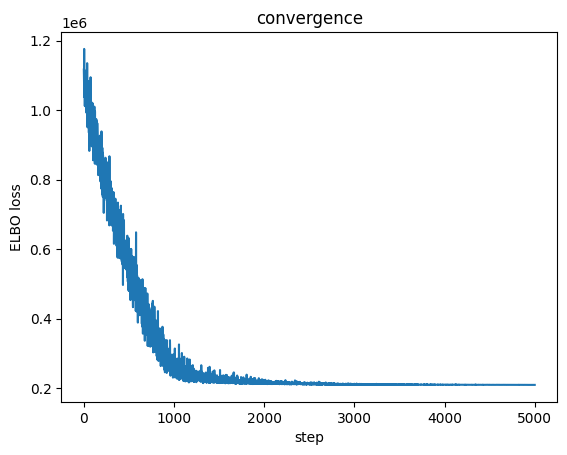

In [42]:
plt.plot(losses1)
plt.xlabel("step")
plt.ylabel("ELBO loss")
plt.title("convergence")
plt.show()

Get the posteriors

In [ ]:
predictive1 = Predictive(model1, guide=guide1, num_samples=1000)
samples1 = predictive1(X_stress_train1, X_weather_train, X_dept_train, X_month_train, None)

w_samples = samples1["w"].detach().squeeze(1).numpy()     
beta_samples = samples1["beta"].detach().squeeze(1).numpy()  
bias_samples = samples1["bias"].detach().squeeze(1).numpy()  

n_weather = X_weather_train.shape[1]  # 2
n_dept = X_dept_train.shape[1]     # 18
n_month = X_month_train.shape[1]    # 11

The stress weights quantify how much each variable contributes to operational stress after accounting for the others.

The reference used was Spirit Airlines, so weights below zero have less effect on stress than the reference. Most carrier weights posteriors are narrow and far from zero (apart from American Airlines, American Eagle Airlines and Mesa Airlines), suggesting the model is confident about carrier specific stress contributions. As said above, the signs reflect carrier stress after controlling for both airport variables, and several carriers show patterns that differ from their EDA delay rates. It could mean that carriers with a high delay rate in EDA and a lower value in their weights have their effect on delay explained by the fact that they mostly operate from delayed airports. Something important to mention is that carriers operating at a small set of airports have limited comparative data, making their weights less reliable.

The weight on departing airport delay rate is positive, narrow and far from zero. This confirms that flying from an airport that usually has delayed flights increases operational stress. 

The weight on previous airport delay rate is clearly negative, which is counterintuitive since flights arriving from airports with a high number of delays should result in more stress. This can be happening due to the fact that 22% of flights had missing previous airport information and were filled with the median delay rate and also because the previous airport delay rate is computed as an average rather than the actual delay status of the inbound flight, which could be a noisy approximation.

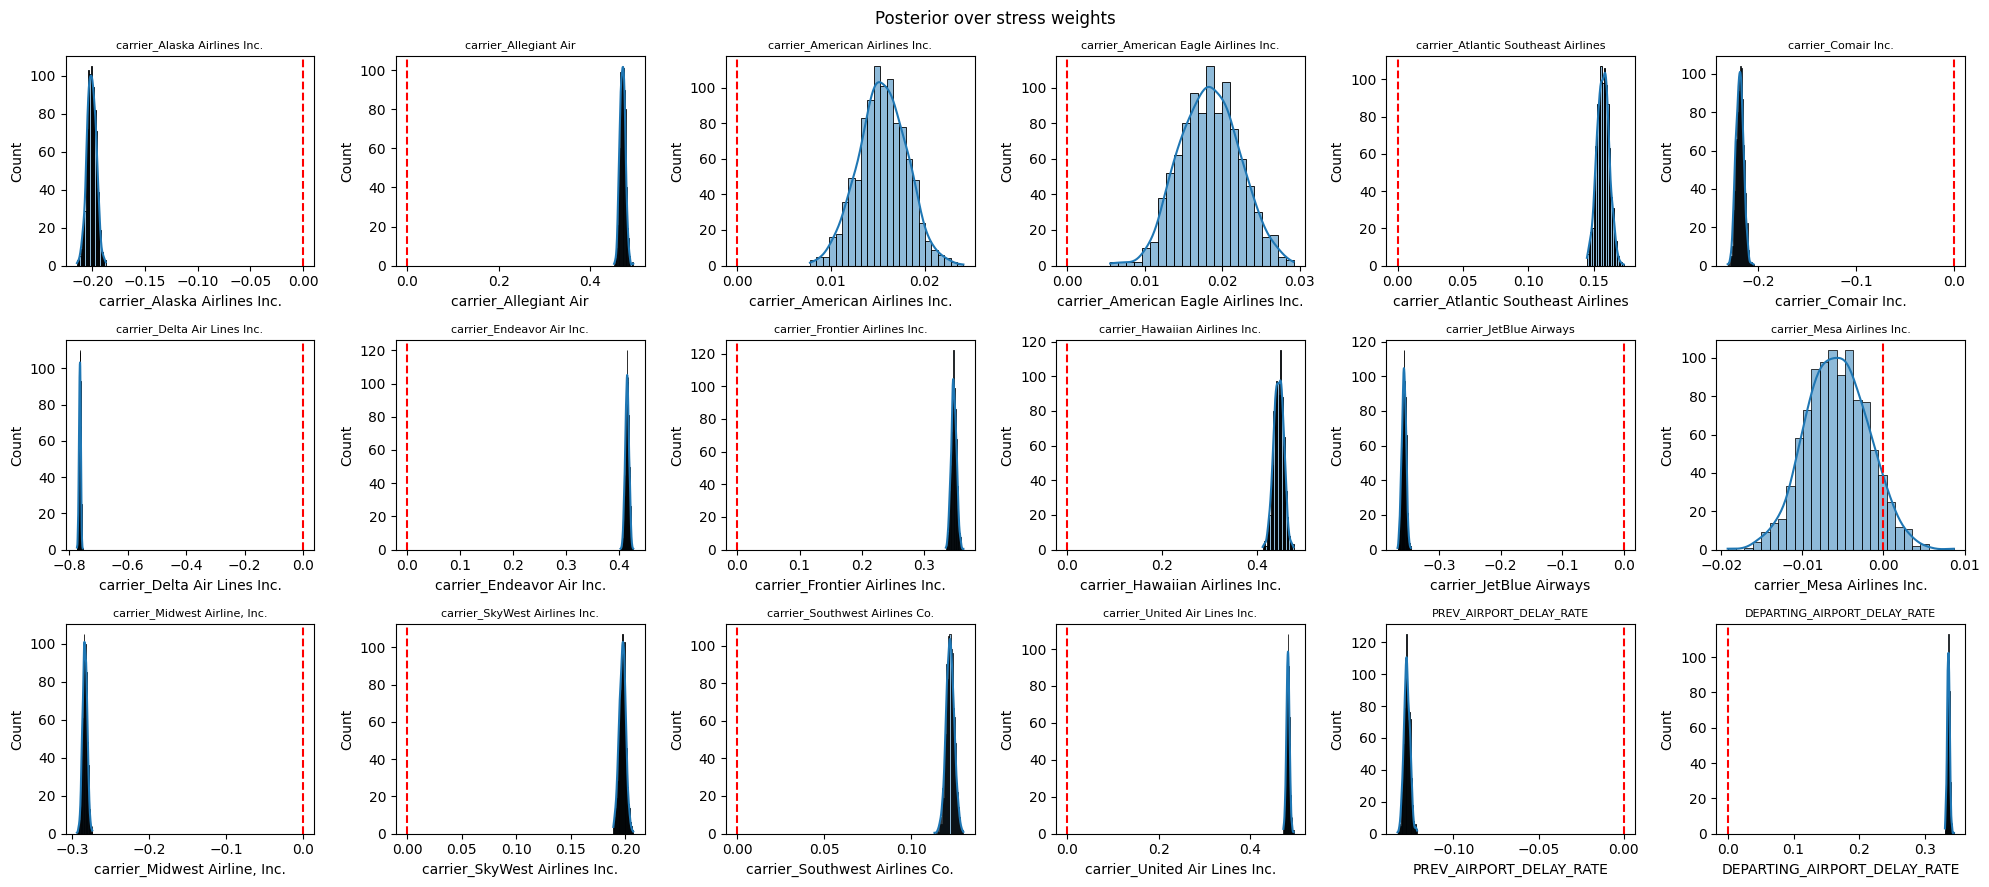

In [45]:
stress_cols1 = carrier_columns_model + ["PREV_AIRPORT_DELAY_RATE", "DEPARTING_AIRPORT_DELAY_RATE"]
w_df = pd.DataFrame(w_samples, columns=stress_cols1)

n_cols = len(stress_cols1)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(w_df.columns):
    sns.histplot(w_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over stress weights")
plt.tight_layout()
plt.show()

Rain and wind posteriors are also positive confirming that more rain and wind is reflected in more delays. Rain appears to have a higher influence and with more certainty, since its mean posterior e higher than wind's and it is also narrower.

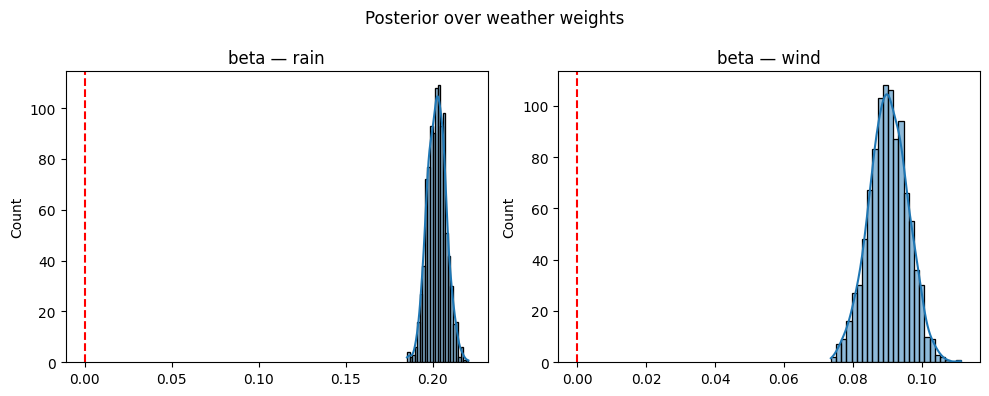

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, (name, idx) in enumerate([("rain", 0), ("wind", 1)]):
    sns.histplot(beta_samples[:, idx], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(f"beta — {name}")
plt.suptitle("Posterior over weather weights")
plt.tight_layout()
plt.show()

The reference used for departure time block is the time block from 0AM to 5:59AM. From the posteriors, we can see that time blocks before 10AM have a negative weight, suggesting they have less delays than the 00AM to 5:59AM block. Then, from 10AM the weights start increasing with the hour and from 12PM they are clearly far away from zero, which aligns with the assumption that flights tend to delay more as you go into the day. Troughout the day, the posterior weights also get narrower, also because most flights happen during the day so there is more data, giving us more certainty on the weights estimates.

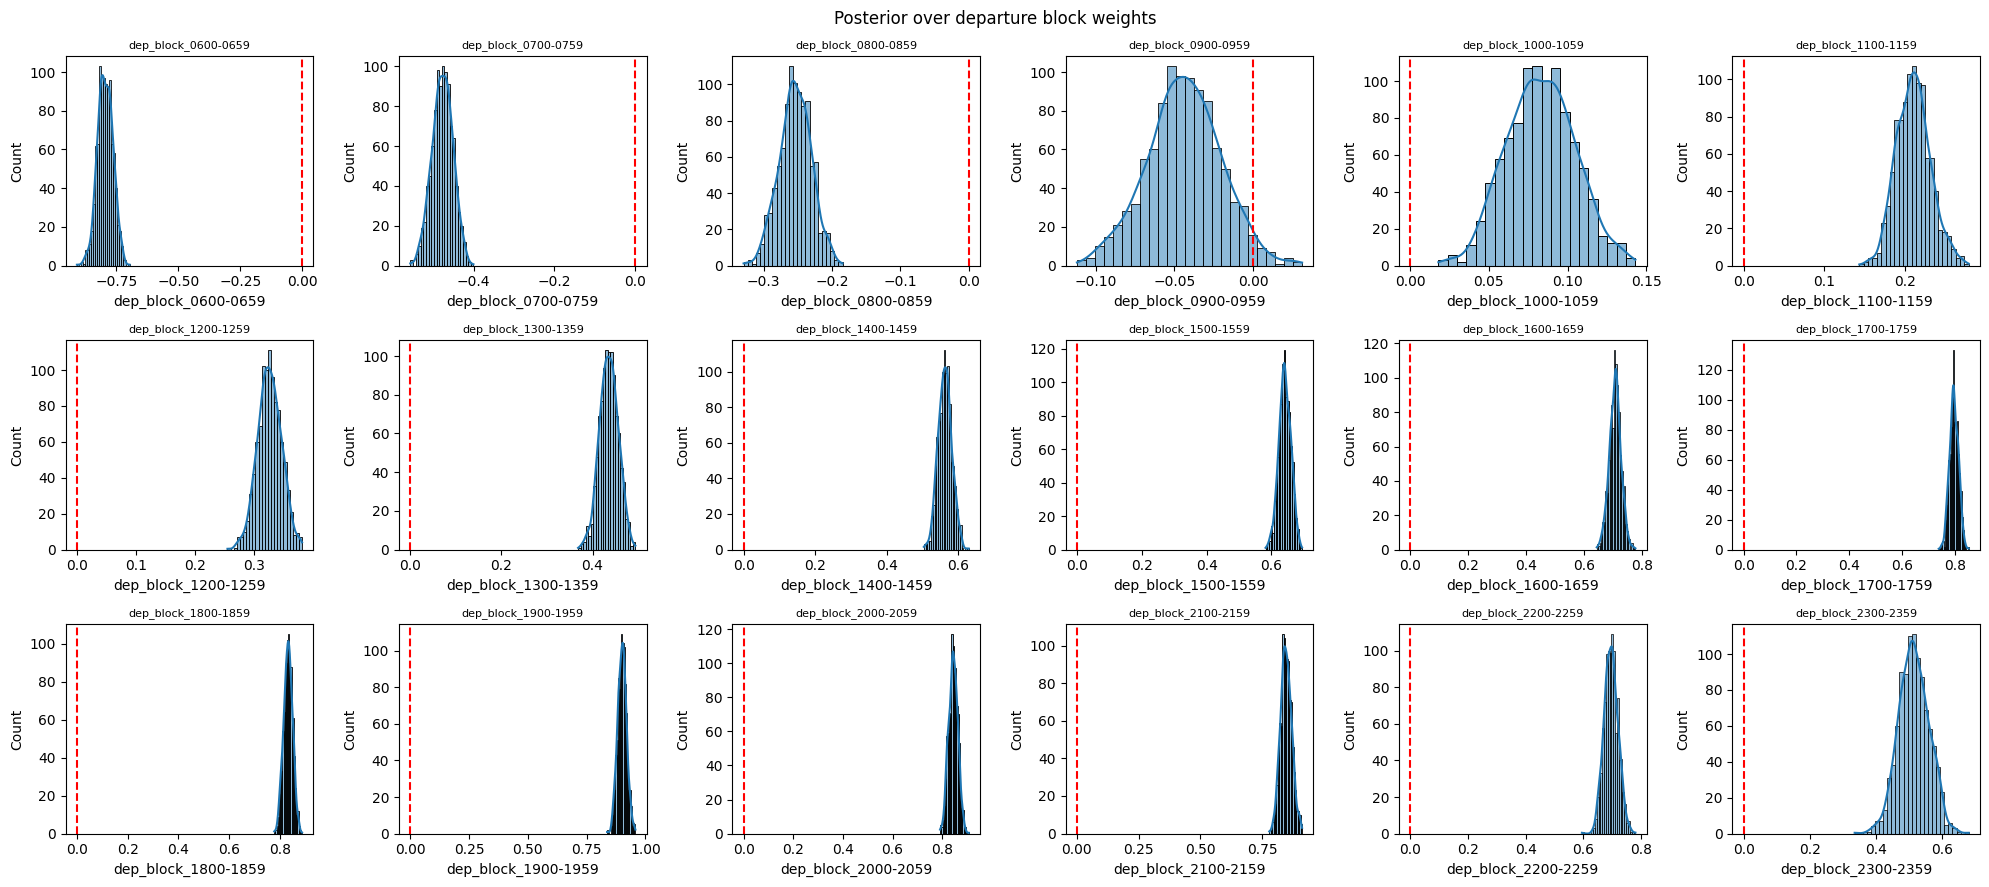

In [47]:
dept_df = pd.DataFrame(beta_samples[:, n_weather:n_weather+n_dept], columns=dpt_columns_model)
n_cols = len(dpt_columns_model)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(dept_df.columns):
    sns.histplot(dept_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over departure block weights")
plt.tight_layout()
plt.show()

The reference month here is April the one with the average delay rate. The June peak is represented here with a large weight posterior and narrow. There is some uncertatinty in some posteriors but overall it looks like the model learned the seasonal pattern.

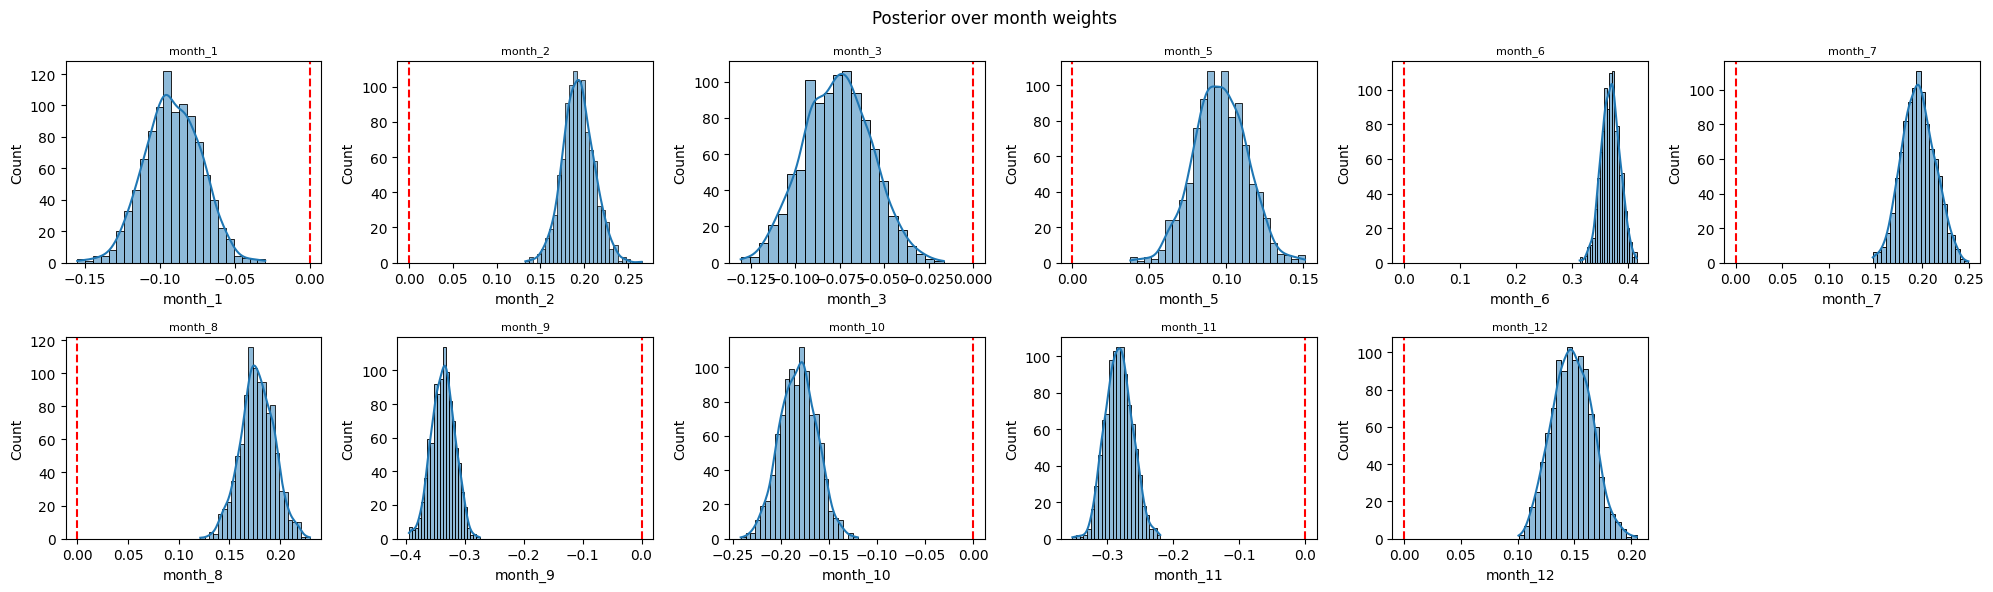

In [ ]:
month_df = pd.DataFrame(beta_samples[:, n_weather+n_dept:n_weather+n_dept+n_month], columns=month_columns_model)
n_cols = len(month_columns_model)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(month_df.columns):
    sns.histplot(month_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over month weights")
plt.tight_layout()
plt.show()

The posterior on stress weight is positive and narrow so the model is confident that higher operational stress increases delay probability.

The bias represents the baseline of delay, meaning a flight with average weather, departing in January (reference month), overnight (reference block), from a Spirit Airlines flight (reference carrier) at an average airport. The posterior mean at around -1.9 corresponds to a baseline delay probability of 13%, below the overall delay rate 19%.

bias:-1.8837 ± 0.0088
Baseline probabilty of delay: 0.1319699224242713


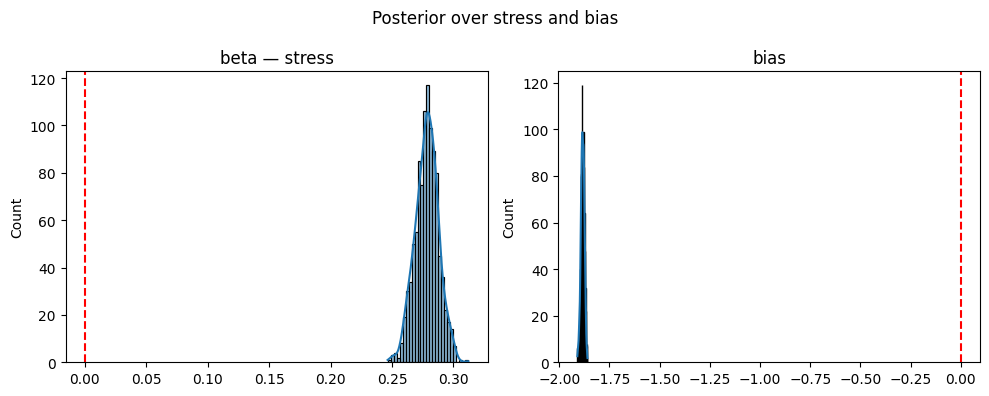

In [53]:
bias_samples = samples1["bias"].detach().squeeze(1).numpy()
base_prob = 1 / (1 + math.exp(-bias_samples.mean()))
print(f"bias:{bias_samples.mean():.4f} ± {bias_samples.std():.4f}")
print(f"Baseline probabilty of delay: {base_prob}")


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(beta_samples[:, -1], ax=axes[0], kde=True)
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("beta — stress")

sns.histplot(bias_samples, ax=axes[1], kde=True)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("bias")
plt.suptitle("Posterior over stress and bias")
plt.tight_layout()
plt.show()

The posterior on sigma_stress is 0.247 with very low uncertainty, indicating the model is confident about the residual stress noise level. This suggests that carrier and airport delay rates capture a meaningful portion of operational stress, but substantial residual variance remains, reflecting unobserved flight-specific factors.

sigma_stress mean: 0.2472
sigma_stress std:  0.0012


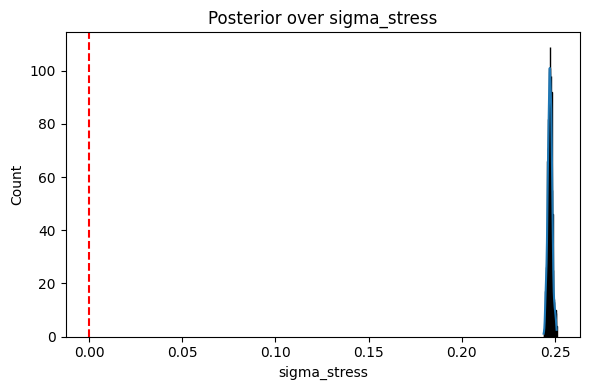

In [51]:
sigma_stress_samples = samples1["sigma_stress"].detach().squeeze(1).numpy()

print(f"sigma_stress mean: {sigma_stress_samples.mean():.4f}")
print(f"sigma_stress std:  {sigma_stress_samples.std():.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(sigma_stress_samples, ax=ax, kde=True)
ax.axvline(0, color="red", linestyle="--")
ax.set_title("Posterior over sigma_stress")
ax.set_xlabel("sigma_stress")
plt.tight_layout()
plt.show()

Posterior predictive check

it's ancestral sampling. You're sampling from the generative model by following the causal chain from top to bottom

You're not checking if the model predicts individual flights correctly — you're checking if the model generates data with the right statistical properties

In [ ]:
w_mean = w_samples.mean(axis=0)     
beta_mean = beta_samples.mean(axis=0)  
bias_mean = bias_samples.mean()        

# compute stress mean
mu_stress = X_stress_train1.numpy() @ w_mean

# sample stress from Normal
sigma_stress_mean = sigma_stress_samples.mean()
stress_train = np.random.normal(mu_stress, sigma_stress_mean)

# then compute logits as before
logits_train = ((X_weather_train.numpy() * beta_mean[0:n_weather]).sum(axis=1) + (X_dept_train.numpy()    * beta_mean[n_weather:n_weather+n_dept]).sum(axis=1) +
    (X_month_train.numpy()   * beta_mean[n_weather+n_dept:n_weather+n_dept+n_month]).sum(axis=1) + beta_mean[-1] * stress_train + bias_mean)

p_train = torch.sigmoid(torch.tensor(logits_train, dtype=torch.float32)).numpy()
y_fake  = np.random.binomial(1, p_train)

print("Real delay rate:", y_train.numpy().mean())
print("Fake delay rate:", y_fake.mean())

Real delay rate: 0.1891448
Fake delay rate: 0.19040186335677206


## Testing

In [68]:
CHUNK = 10000
p_mean_list = []
p_std_list  = []

for i in range(0, len(X_stress_test1), CHUNK):
    X_s = X_stress_test1[i:i+CHUNK].numpy()
    X_w = X_weather_test[i:i+CHUNK].numpy()
    X_d = X_dept_test[i:i+CHUNK].numpy()
    X_m = X_month_test[i:i+CHUNK].numpy()

    # for each posterior sample compute a prediction
    p_samples_chunk = []
    for s in range(len(w_samples)):

        mu_stress = X_s @ w_samples[s]
        stress = np.random.normal(mu_stress, sigma_stress_samples[s])

        logits = ((X_w * beta_samples[s, 0:n_weather]).sum(axis=1) + (X_d * beta_samples[s, n_weather:n_weather+n_dept]).sum(axis=1) +
        (X_m * beta_samples[s, n_weather+n_dept:n_weather+n_dept+n_month]).sum(axis=1) + beta_samples[s, -1] * stress + bias_samples[s])
        
        p_samples_chunk.append(torch.sigmoid(torch.tensor(logits, dtype=torch.float32)).numpy())

    p_chunk = np.stack(p_samples_chunk)  # (1000, chunk_size)
    p_mean_list.append(p_chunk.mean(axis=0))
    p_std_list.append(p_chunk.std(axis=0))

p_mean = np.concatenate(p_mean_list)
p_std  = np.concatenate(p_std_list)
#y_pred = (p_mean > 0.5).astype(float)

# TO DO

In [ ]:
y_test_np = y_test.numpy()

# threshold free
print(f"AUC-ROC: {roc_auc_score(y_test_np, p_mean):.4f}")

# optimal threshold
from sklearn.metrics import f1_score
thresholds = np.arange(0.05, 0.40, 0.01)
f1_scores = [f1_score(y_test_np, (p_mean > t).astype(float)) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]
y_pred_best = (p_mean > best_t).astype(float)

print(f"Optimal threshold: {best_t:.2f}")
print(classification_report(y_test_np, y_pred_best))

AUC-ROC: 0.6606
Optimal threshold: 0.20
              precision    recall  f1-score   support

         0.0       0.87      0.61      0.72   1578509
         1.0       0.27      0.62      0.38    368210

    accuracy                           0.61   1946719
   macro avg       0.57      0.61      0.55   1946719
weighted avg       0.76      0.61      0.66   1946719



In [61]:
threshold = np.percentile(p_std, 90)
uncertain_flights = p_std > threshold

print("=== Uncertainty Analysis ===")
print(f"Uncertainty threshold (90th percentile): {threshold:.4f}")
print(f"High uncertainty flights: {uncertain_flights.sum()}")

print("\nHigh uncertainty flights:")
print(f"  Mean p_std:  {p_std[uncertain_flights].mean():.4f}")
print(f"  Delay rate:  {y_test.numpy()[uncertain_flights].mean():.4f}")

print("\nLow uncertainty flights (bottom 10%):")
low_unc = p_std < np.percentile(p_std, 10)
print(f"  Mean p_std:  {p_std[low_unc].mean():.4f}")
print(f"  Delay rate:  {y_test.numpy()[low_unc].mean():.4f}")

=== Uncertainty Analysis ===
Uncertainty threshold (90th percentile): 0.0158
High uncertainty flights: 194672

High uncertainty flights:
  Mean p_std:  0.0172
  Delay rate:  0.3747

Low uncertainty flights (bottom 10%):
  Mean p_std:  0.0046
  Delay rate:  0.0693


## Results

Model 1 defined stress as a linear combination of carrier identity (one hot encoded), previous airport delay rate and departing airport delay rate, and delay as a linear combination of rain, wind, departure block, month and stress.

The model converged well — the posterior predictive check showed a fake delay rate of 19.1% against a real rate of 18.9%, confirming the model correctly captures the overall delay distribution. The AUC-ROC of 0.6605 represents 

The posterior distributions revealed several meaningful patterns. Rain and wind coefficients were clearly positive and confident, consistent with their direct physical effect on delay. Departure block weights followed the expected temporal pattern — early morning flights showed negative coefficients relative to the overnight reference, while afternoon and evening blocks showed increasingly positive coefficients, peaking around 18:00-20:00. Month weights correctly identified June as the highest delay month and September-November as the lowest, matching the EDA findings.

The uncertainty analysis showed that the model's epistemic uncertainty is genuinely informative — flights in the top 10% of uncertainty had a 35.4% actual delay rate compared to 6.9% for the most certain predictions, demonstrating that p_std captures real signal about flight risk beyond the point prediction.

However two problems emerged. First, the previous airport delay rate had a negative coefficient — counterintuitive since flights coming from delay-prone airports should be more likely to delay. This suggests possible collinearity with the departing airport delay rate. Second, carrier one hot encoding produced inconsistent signs — some carriers that are empirically more delay-prone showed negative coefficients, likely due to the reference category choice and lack of information sharing between carriers. These issues motivate the changes in Model 2.


# 4. Model 2


Model 1 revealed two problems — carrier one hot encoding produced inconsistent signs due to the reference category issue, and previous airport delay rate had a counterintuitive negative sign. Model 2 addresses these by switching to a hierarchical carrier model and dropping the problematic previous airport variable

Despite a theoretically motivated inclusion, previous airport delay rate showed a counterintuitive negative coefficient in Model 1. Given the 22% missing value rate and noisy estimation for small airports, it was dropped from Model 2."

In [ ]:
def model2(carrier_idx, X_stress_cont, X_weather, X_dept, X_month, y):

    n_carriers = len(carrier_categories)
    n_stress = X_stress_cont.shape[1]  
    n_weather = X_weather.shape[1]      
    n_dept = X_dept.shape[1]         
    n_month = X_month.shape[1]        
    n_delay = n_weather + n_dept + n_month + 1  

    # hyperpriors on carrier baselines
    mu_alpha = pyro.sample("mu_alpha", dist.Normal(0., 1.))
    sigma_alpha = pyro.sample("sigma_alpha", dist.HalfNormal(1.))

    # carrier baselines 
    alpha_carrier = pyro.sample("alpha_carrier", dist.Normal(mu_alpha * torch.ones(n_carriers), sigma_alpha * torch.ones(n_carriers)).to_event(1))

    # continuous stress weight
    w_dep = pyro.sample("w_dep", dist.Normal(0., 1.))
    sigma_stress = pyro.sample("sigma_stress", dist.HalfNormal(1.0))

    # delay priors 
    beta = pyro.sample("beta", dist.Normal(torch.zeros(n_delay), torch.ones(n_delay)).to_event(1))
    bias = pyro.sample("bias", dist.Normal(0., 1.))

    with pyro.plate("flights", X_weather.shape[0]):

        # stress mean
        mu_stress = (alpha_carrier[..., carrier_idx] + w_dep * X_stress_cont[:, 0])
        stress = pyro.sample("stress", dist.Normal(mu_stress, sigma_stress))

        # delay logits
        logits = ((X_weather * beta[..., 0:n_weather]).sum(dim=-1) + (X_dept * beta[..., n_weather:n_weather+n_dept]).sum(dim=-1) +
            (X_month * beta[..., n_weather+n_dept:n_weather+n_dept+n_month]).sum(dim=-1) + beta[..., -1] * stress + bias)

        obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    return obs

## Training

In [71]:
pyro.clear_param_store()
torch.manual_seed(42)
pyro.set_rng_seed(42)

guide2 = AutoDiagonalNormal(model2)

# setup
adam_params = {"lr": 0.001}
optimizer = ClippedAdam(adam_params)
elbo = Trace_ELBO(num_particles=1)
svi = SVI(model2, guide2, optimizer, loss=elbo)

n_steps = 5000

losses2 = []
for step in range(n_steps):
    loss = svi.step(carrier_idx_train2, X_stress_train2, X_weather_train, X_dept_train, X_month_train, y_train)
    losses2.append(loss)
    if step % 1000 == 0:
        print(f"[{step}] loss: {loss:.1f}")

[0] loss: 939044.7
[1000] loss: 241750.0
[2000] loss: 214435.4
[3000] loss: 211149.4
[4000] loss: 209745.3


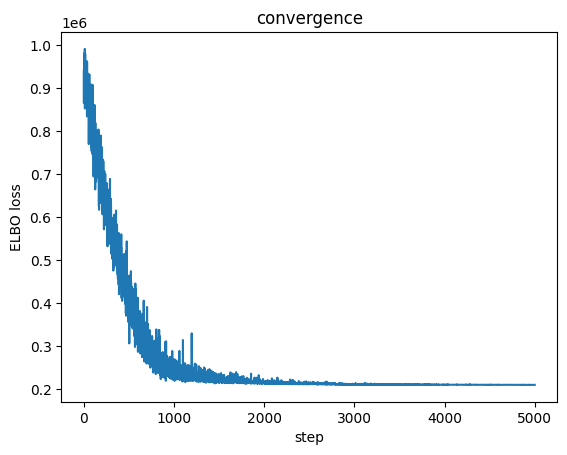

In [72]:
plt.plot(losses2)
plt.xlabel("step")
plt.ylabel("ELBO loss")
plt.title("convergence")
plt.show()

In [73]:
predictive2 = Predictive(model2, guide=guide2, num_samples=1000)
samples2 = predictive2(carrier_idx_train2, X_stress_train2, X_weather_train, X_dept_train, X_month_train, None)

# extract samples
alpha_carrier_samples = samples2["alpha_carrier"].detach().squeeze(1).numpy() 
mu_alpha_samples = samples2["mu_alpha"].detach().squeeze(1).numpy()        
sigma_alpha_samples = samples2["sigma_alpha"].detach().squeeze(1).numpy()     
w_dep_samples = samples2["w_dep"].detach().squeeze(1).numpy()           
beta_samples = samples2["beta"].detach().squeeze(1).numpy()            
bias_samples = samples2["bias"].detach().squeeze(1).numpy()            

n_weather = X_weather_train.shape[1]  # 2
n_dept = X_dept_train.shape[1]     # 18
n_month = X_month_train.shape[1]    # 11

print("Hyperpriors")
print(f"mu_alpha: {mu_alpha_samples.mean()} ± {mu_alpha_samples.std()}")
print(f"sigma_alpha: {sigma_alpha_samples.mean()} ± {sigma_alpha_samples.std()}")

print("\nCarrier baselines")
for i, carrier in enumerate(carrier_categories):
    print(f" {carrier}: {alpha_carrier_samples[:, i].mean()} ± {alpha_carrier_samples[:, i].std()}")

print(f"\nStress weight")
print(f"w_dep: {w_dep_samples.mean()} ± {w_dep_samples.std()}")

print("\nDelay weights")
print(f"beta_rain: {beta_samples[:, 0].mean()} ± {beta_samples[:, 0].std()}")
print(f"beta_wind: {beta_samples[:, 1].mean()} ± {beta_samples[:, 1].std()}")

print("\nDeparture blocks:")
for i, col in enumerate(dpt_columns_model):
    print(f"{col}: {beta_samples[:, n_weather+i].mean()} ± {beta_samples[:, n_weather+i].std()}")

print("\nMonths:")
for i, col in enumerate(month_columns_model):
    print(f" {col}: {beta_samples[:, n_weather+n_dept+i].mean()} ± {beta_samples[:, n_weather+n_dept+i].std()}")

print(f"\nbeta_stress: {beta_samples[:, -1].mean()} ± {beta_samples[:, -1].std()}")
print(f"bias: {bias_samples.mean()} ± {bias_samples.std()}")

Hyperpriors
mu_alpha: 0.32660606503486633 ± 0.062059227377176285
sigma_alpha: 0.26605644822120667 ± 0.049278244376182556

Carrier baselines
 Alaska Airlines Inc.: 0.5147027373313904 ± 0.0038083733525127172
 Allegiant Air: 0.4078650176525116 ± 0.005357148591428995
 American Airlines Inc.: 0.20626607537269592 ± 0.0023080173414200544
 American Eagle Airlines Inc.: 0.001918398542329669 ± 0.0036760701332241297
 Atlantic Southeast Airlines: 0.6341758370399475 ± 0.004105892963707447
 Comair Inc.: 0.04081607237458229 ± 0.0030556442216038704
 Delta Air Lines Inc.: 0.4736059606075287 ± 0.0027401093393564224
 Endeavor Air Inc.: 0.48922717571258545 ± 0.003340041032060981
 Frontier Airlines Inc.: 0.9590914249420166 ± 0.003747297450900078
 Hawaiian Airlines Inc.: 0.24638496339321136 ± 0.00884220376610756
 JetBlue Airways: -0.02912219427525997 ± 0.003092891303822398
 Mesa Airlines Inc.: 0.3296031355857849 ± 0.003187823574990034
 Midwest Airline, Inc.: 0.1361956149339676 ± 0.0027055509854108095
 SkyWe

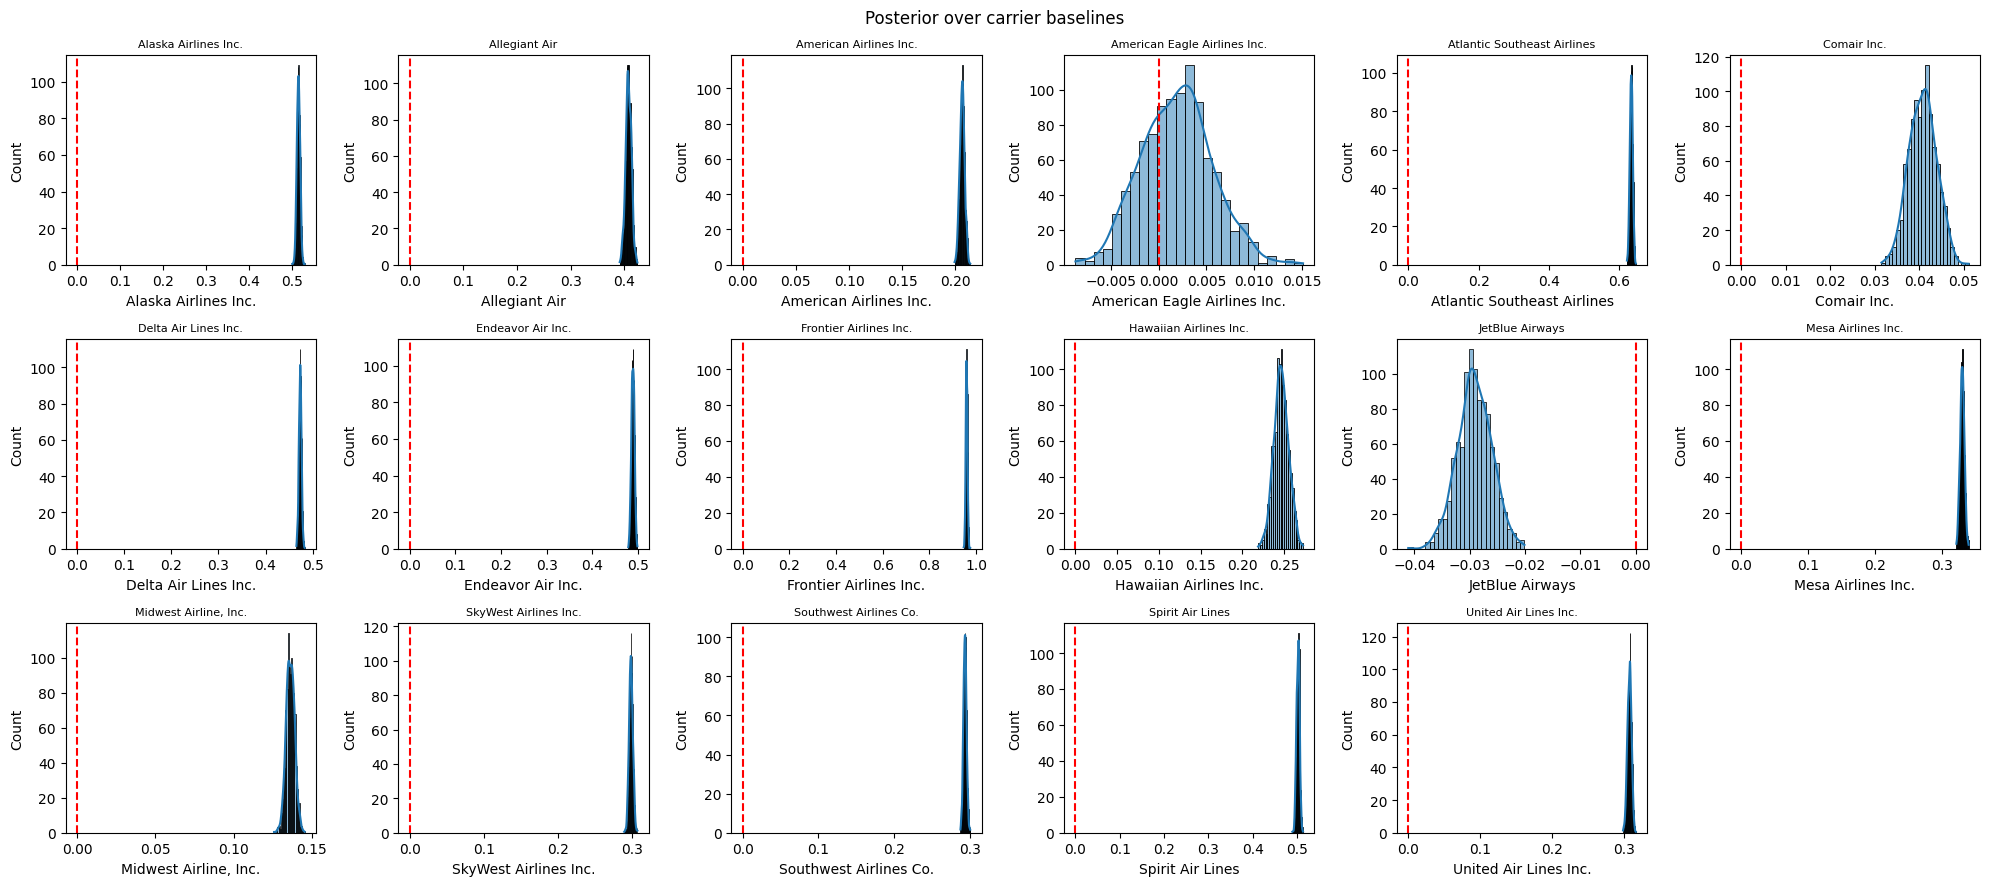

In [79]:
alpha_df = pd.DataFrame(alpha_carrier_samples, columns=carrier_categories.tolist())
n_cols = len(carrier_categories)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(alpha_df.columns):
    sns.histplot(alpha_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over carrier baselines")
plt.tight_layout()
plt.show()

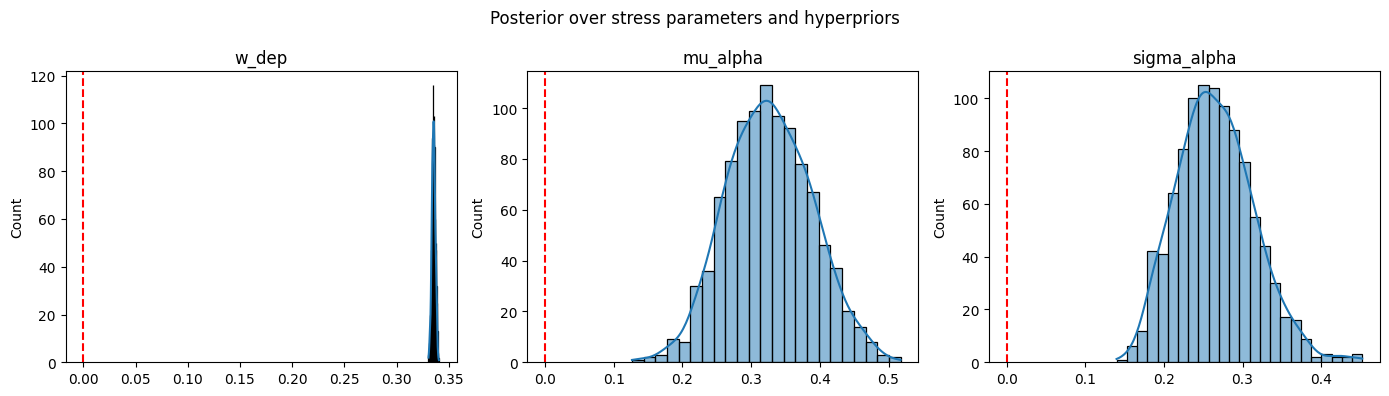

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, samples, name in zip(axes,[w_dep_samples, mu_alpha_samples, sigma_alpha_samples],["w_dep", "mu_alpha", "sigma_alpha"]):
    sns.histplot(samples, ax=ax, kde=True)
    ax.axvline(0, color="red", linestyle="--")
    ax.set_title(name)
plt.suptitle("Posterior over stress parameters and hyperpriors")
plt.tight_layout()
plt.show()

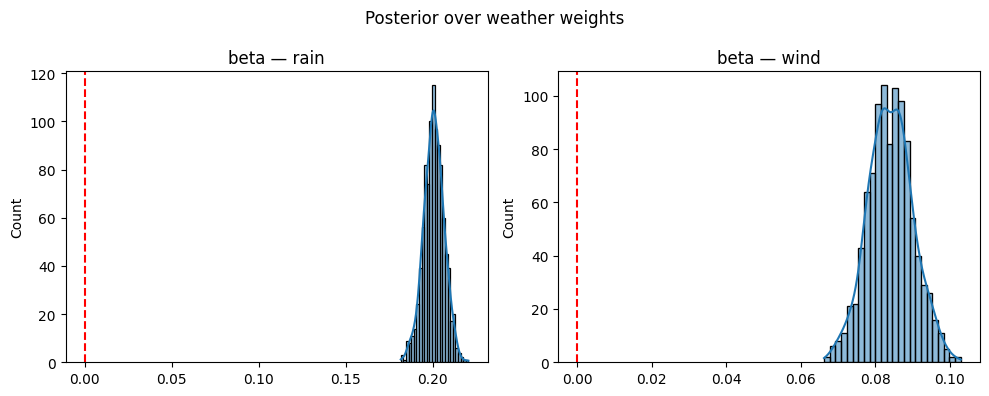

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, (name, idx) in enumerate([("rain", 0), ("wind", 1)]):
    sns.histplot(beta_samples[:, idx], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(f"beta — {name}")
plt.suptitle("Posterior over weather weights")
plt.tight_layout()
plt.show()

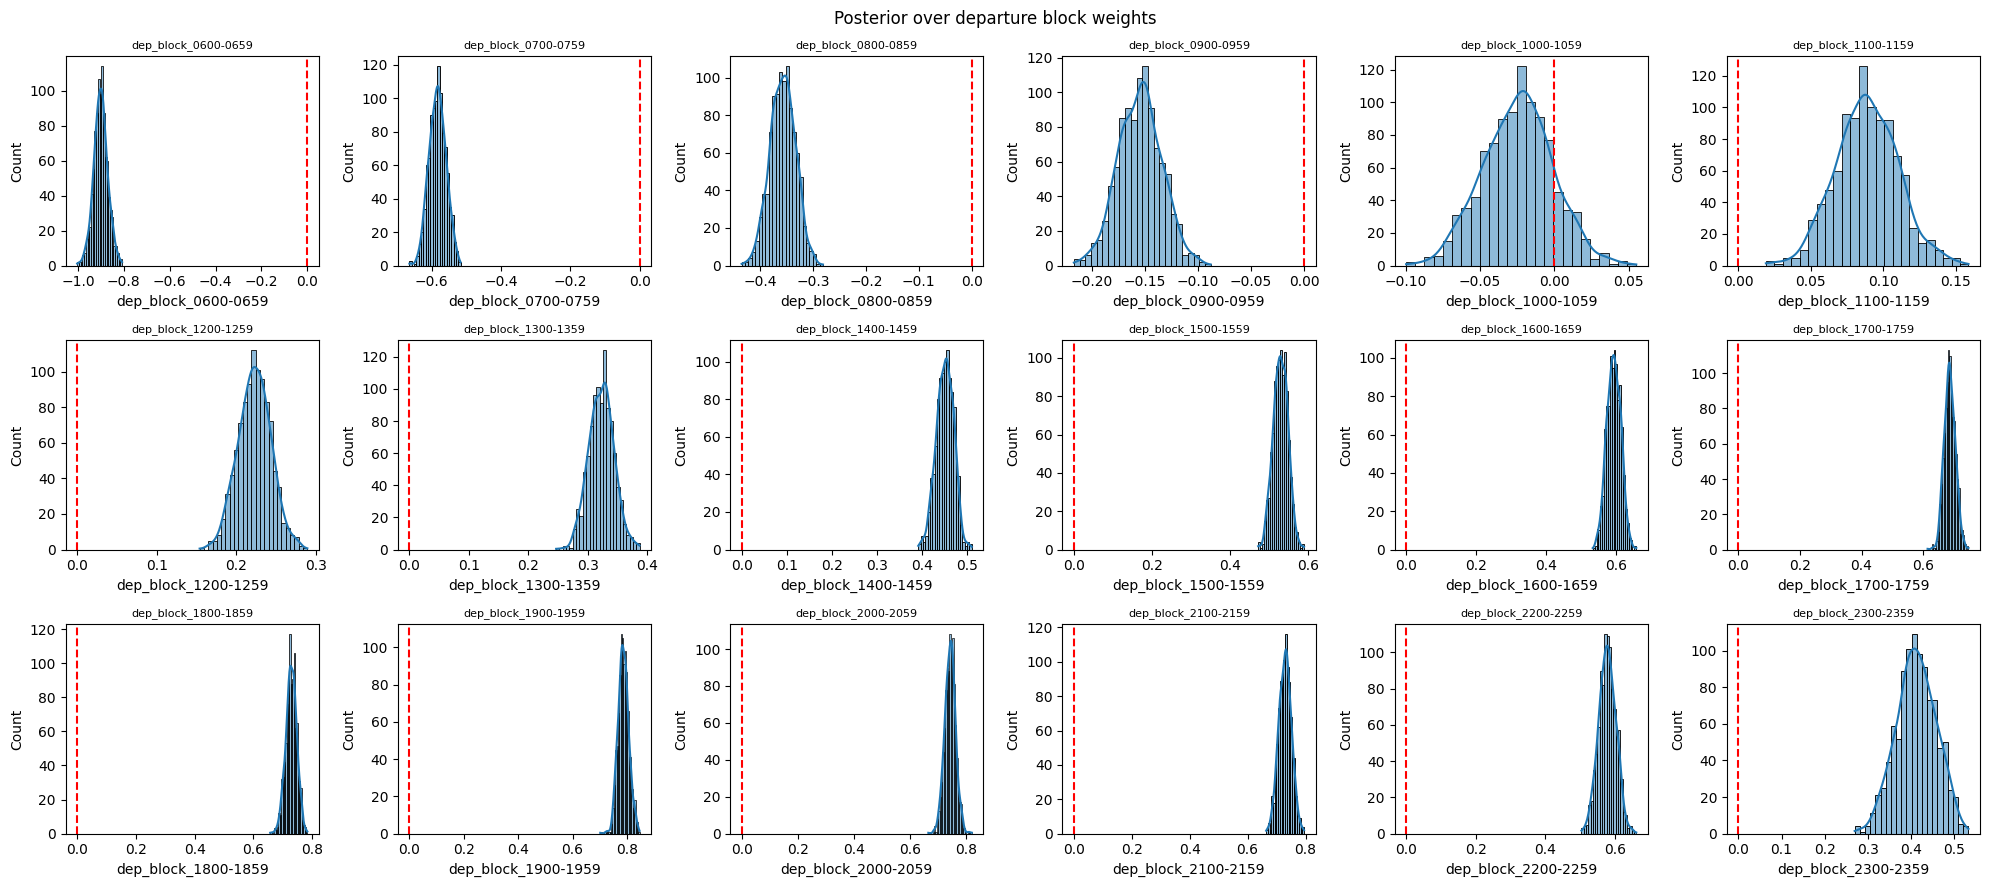

In [82]:
dept_df = pd.DataFrame(beta_samples[:, n_weather:n_weather+n_dept], columns=dpt_columns_model)
n_cols = len(dpt_columns_model)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(dept_df.columns):
    sns.histplot(dept_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
    
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over departure block weights")
plt.tight_layout()
plt.show()

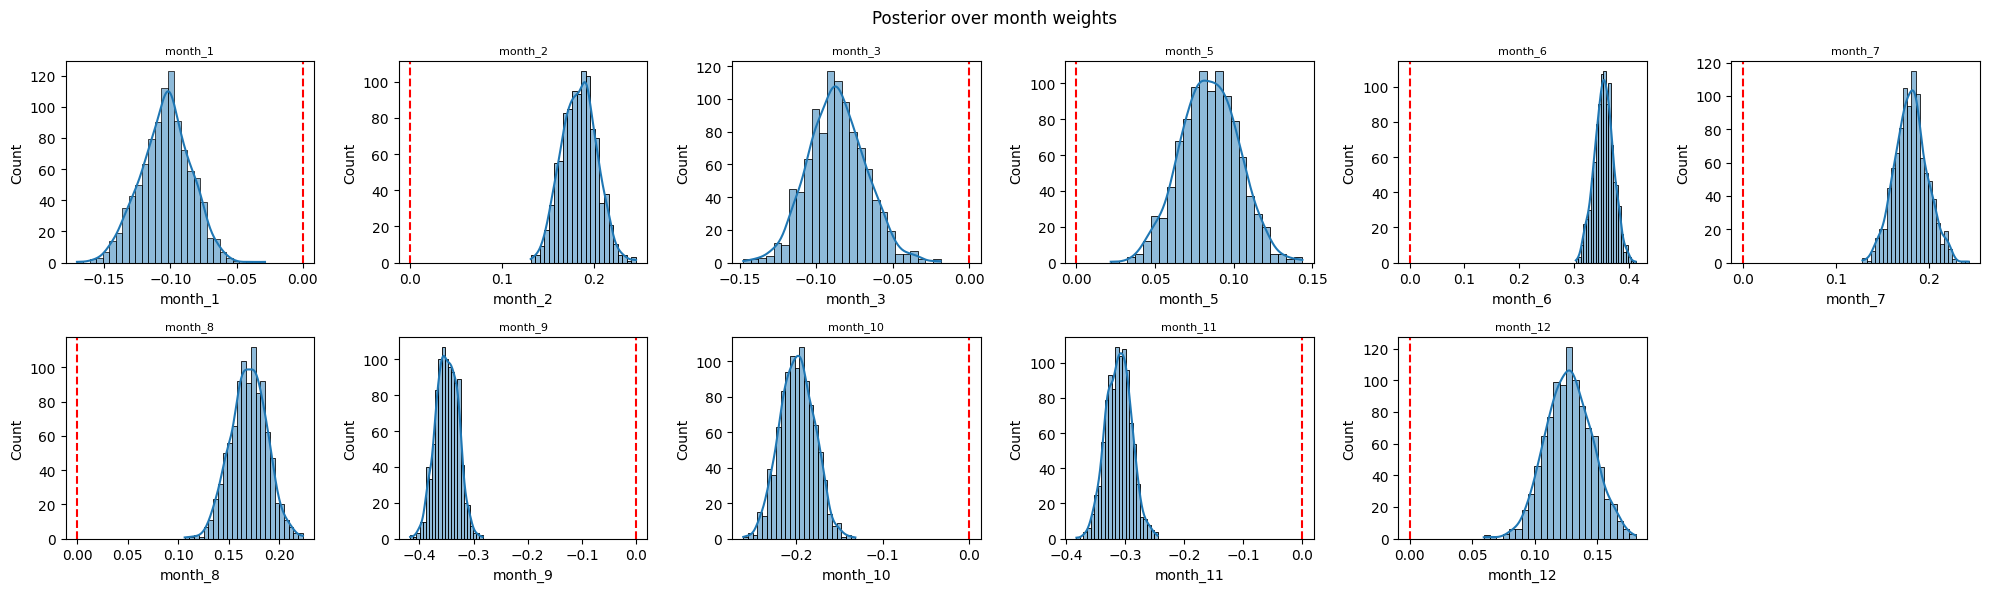

In [83]:

# ── month weights ──
month_df = pd.DataFrame(beta_samples[:, n_weather+n_dept:n_weather+n_dept+n_month],
                         columns=month_columns_model)
n_cols = len(month_columns_model)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(month_df.columns):
    sns.histplot(month_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over month weights")
plt.tight_layout()
plt.show()

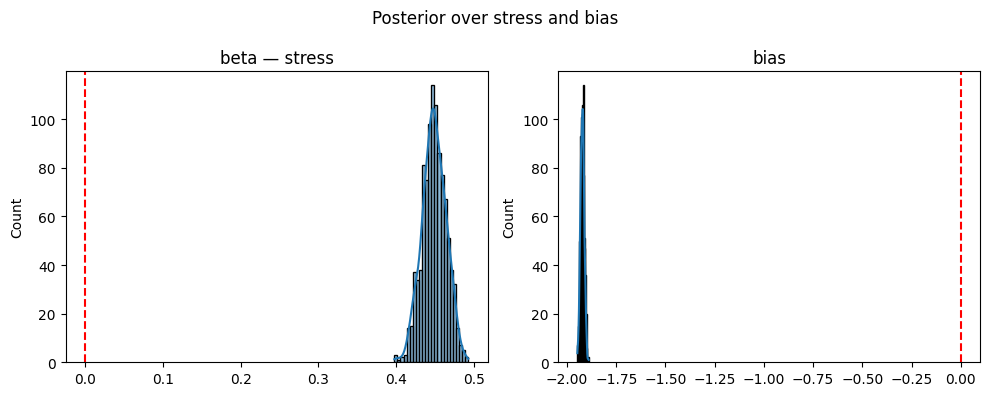

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(beta_samples[:, -1], ax=axes[0], kde=True)
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("beta — stress")

sns.histplot(bias_samples, ax=axes[1], kde=True)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("bias")
plt.suptitle("Posterior over stress and bias")
plt.tight_layout()
plt.show()

sigma_stress mean: 0.2104
sigma_stress std:  0.0008


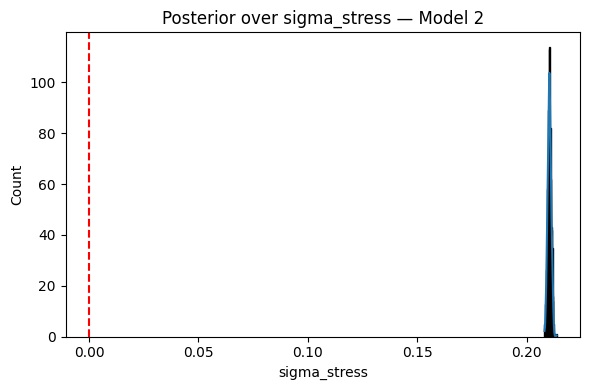

In [85]:
sigma_stress_samples2 = samples2["sigma_stress"].detach().squeeze(1).numpy()

print(f"sigma_stress mean: {sigma_stress_samples2.mean():.4f}")
print(f"sigma_stress std:  {sigma_stress_samples2.std():.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(sigma_stress_samples2, ax=ax, kde=True)
ax.axvline(0, color="red", linestyle="--")
ax.set_title("Posterior over sigma_stress — Model 2")
ax.set_xlabel("sigma_stress")
plt.tight_layout()
plt.show()

Posterior predictive check

In [ ]:
# get posterior means
alpha_carrier_mean = alpha_carrier_samples.mean(axis=0)  
w_dep_mean = w_dep_samples.mean()                 
beta_mean = beta_samples.mean(axis=0)            
bias_mean = bias_samples.mean()                  

mu_stress = (alpha_carrier_mean[carrier_idx_train2.numpy()] + w_dep_mean * X_stress_train2.numpy().squeeze())
stress_train = np.random.normal(mu_stress, sigma_stress_mean)

logits_train = ((X_weather_train.numpy() * beta_mean[0:n_weather]).sum(axis=1) + (X_dept_train.numpy() * beta_mean[n_weather:n_weather+n_dept]).sum(axis=1) +
    (X_month_train.numpy() * beta_mean[n_weather+n_dept:n_weather+n_dept+n_month]).sum(axis=1) + beta_mean[-1] * stress_train + bias_mean)

p_train = torch.sigmoid(torch.tensor(logits_train, dtype=torch.float32)).numpy()
y_fake = np.random.binomial(1, p_train)

print("Real delay rate:", y_train.numpy().mean())
print("Fake delay rate:", y_fake.mean())

Real delay rate: 0.1891448
Fake delay rate: 0.18995275562815642


## Testing

In [88]:
# get posterior samples
alpha_carrier_samples = samples2["alpha_carrier"].detach().squeeze(1).numpy()  
w_dep_samples = samples2["w_dep"].detach().squeeze(1).numpy()          
beta_samples = samples2["beta"].detach().squeeze(1).numpy()            
bias_samples = samples2["bias"].detach().squeeze(1).numpy()           

CHUNK = 10000
p_mean_list = []
p_std_list = []

for i in range(0, len(X_weather_test), CHUNK):
    X_w = X_weather_test[i:i+CHUNK].numpy()
    X_d = X_dept_test[i:i+CHUNK].numpy()
    X_m = X_month_test[i:i+CHUNK].numpy()
    c_idx = carrier_idx_test2[i:i+CHUNK].numpy()
    x_dep = X_stress_test2[i:i+CHUNK].numpy().squeeze()

    p_samples_chunk = []
    for s in range(len(alpha_carrier_samples)):
    
        mu_stress = (alpha_carrier_samples[s, c_idx] + w_dep_samples[s] * x_dep)
        stress = np.random.normal(mu_stress, sigma_stress_samples2[s])

        logits = ((X_w * beta_samples[s, 0:n_weather]).sum(axis=1) + (X_d * beta_samples[s, n_weather:n_weather+n_dept]).sum(axis=1) +
            (X_m * beta_samples[s, n_weather+n_dept:n_weather+n_dept+n_month]).sum(axis=1) + beta_samples[s, -1] * stress + bias_samples[s])
        
        p_samples_chunk.append(torch.sigmoid(torch.tensor(logits, dtype=torch.float32)).numpy())

    p_chunk = np.stack(p_samples_chunk)  
    p_mean_list.append(p_chunk.mean(axis=0))
    p_std_list.append(p_chunk.std(axis=0))

p_mean = np.concatenate(p_mean_list)
p_std = np.concatenate(p_std_list)

In [89]:
y_test_np = y_test.numpy()

print("=== Test Evaluation ===")
print(f"Real delay rate:      {y_test_np.mean():.4f}")
print(f"Predicted delay rate: {y_pred.mean():.4f}")
print(f"Accuracy:  {accuracy_score(y_test_np, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_np, p_mean):.4f}")
print(classification_report(y_test_np, y_pred))

=== Test Evaluation ===
Real delay rate:      0.1891
Predicted delay rate: 0.0046
Accuracy:  0.8113
AUC-ROC:   0.6603
              precision    recall  f1-score   support

         0.0       0.81      1.00      0.90   1578509
         1.0       0.55      0.01      0.03    368210

    accuracy                           0.81   1946719
   macro avg       0.68      0.51      0.46   1946719
weighted avg       0.76      0.81      0.73   1946719



In [90]:
threshold = np.percentile(p_std, 90)
uncertain_flights = p_std > threshold

print("=== Uncertainty Analysis ===")
print(f"Uncertainty threshold (90th percentile): {threshold:.4f}")
print(f"High uncertainty flights: {uncertain_flights.sum()}")

print("\nHigh uncertainty flights:")
print(f"  Mean p_std:  {p_std[uncertain_flights].mean():.4f}")
print(f"  Delay rate:  {y_test.numpy()[uncertain_flights].mean():.4f}")

print("\nLow uncertainty flights (bottom 10%):")
low_unc = p_std < np.percentile(p_std, 10)
print(f"  Mean p_std:  {p_std[low_unc].mean():.4f}")
print(f"  Delay rate:  {y_test.numpy()[low_unc].mean():.4f}")

=== Uncertainty Analysis ===
Uncertainty threshold (90th percentile): 0.0067
High uncertainty flights: 194672

High uncertainty flights:
  Mean p_std:  0.0080
  Delay rate:  0.3624

Low uncertainty flights (bottom 10%):
  Mean p_std:  0.0020
  Delay rate:  0.0709


Model 2 replaced carrier one hot encoding with a hierarchical random effects model and dropped the previous airport delay rate which showed an unexpected negative sign. The AUC-ROC remained essentially unchanged at 0.6603, but the model improved in two important ways. First, the carrier baselines became interpretable — Frontier and Atlantic Southeast show the highest stress baselines, consistent with their high delay rates in the EDA. Second, the stress coefficient increased from 0.28 to 0.43, suggesting the stress variable is capturing more genuine operational signal after removing the noisy previous airport variable. The uncertainty analysis remained strong — high uncertainty flights delayed at 36.2% vs 7.0% for low uncertainty flights, confirming that epistemic uncertainty is a meaningful predictor of delay risk

In [91]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

# use all your features as flat inputs
X_train_flat = np.concatenate([
    X_weather_train.numpy(),
    X_stress_train1.numpy(),
    X_dept_train.numpy(),
    X_month_train.numpy()
], axis=1)

X_test_flat = np.concatenate([
    X_weather_test.numpy(),
    X_stress_test1.numpy(),
    X_dept_test.numpy(),
    X_month_test.numpy()
], axis=1)

gb = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
gb.fit(X_train_flat, y_train.numpy())

p_gb = gb.predict_proba(X_test_flat)[:, 1]
print("GBM AUC-ROC:", roc_auc_score(y_test.numpy(), p_gb))

GBM AUC-ROC: 0.6791721916395591


# 5. Model 3

In [89]:
def model3(carrier_idx, X_stress_cont, X_weather, X_dept, X_month, y):

    n_carriers = len(carrier_categories)
    n_stress   = X_stress_cont.shape[1]  
    n_weather  = X_weather.shape[1]      
    n_dept     = X_dept.shape[1]         
    n_month    = X_month.shape[1]        
    n_delay    = n_weather + n_dept + n_month + 1  # +1 for stress linear term

    # ── hyperpriors on carrier baselines ──
    mu_alpha    = pyro.sample("mu_alpha",    dist.Normal(0., 1.))
    sigma_alpha = pyro.sample("sigma_alpha", dist.HalfNormal(1.))

    # ── carrier baselines ──
    alpha_carrier = pyro.sample("alpha_carrier",
                                dist.Normal(mu_alpha * torch.ones(n_carriers),
                                           sigma_alpha * torch.ones(n_carriers)).to_event(1))

    # ── stress parameters ──
    w_dep        = pyro.sample("w_dep",        dist.Normal(0., 1.))
    sigma_stress = pyro.sample("sigma_stress", dist.HalfNormal(1.0))

    # ── delay parameters ──
    beta         = pyro.sample("beta",         dist.Normal(torch.zeros(n_delay),
                                                           torch.ones(n_delay)).to_event(1))
    beta_stress2 = pyro.sample("beta_stress2", dist.Normal(0., 1.))  # quadratic term
    bias         = pyro.sample("bias",         dist.Normal(0., 1.))

    with pyro.plate("flights", X_weather.shape[0]):

        # stress mean
        mu_stress = (alpha_carrier[..., carrier_idx] + 
                     w_dep * X_stress_cont[:, 0])
        stress = pyro.sample("stress", dist.Normal(mu_stress, sigma_stress))

        # delay logits — now with quadratic stress term
        logits = (
            (X_weather * beta[..., 0:n_weather]).sum(dim=-1) +
            (X_dept    * beta[..., n_weather:n_weather+n_dept]).sum(dim=-1) +
            (X_month   * beta[..., n_weather+n_dept:n_weather+n_dept+n_month]).sum(dim=-1) +
            beta[..., -1] * stress +       # linear stress term
            beta_stress2   * stress**2 +   # quadratic stress term
            bias
        )

        obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    return obs

In [90]:
pyro.clear_param_store()
torch.manual_seed(42)
pyro.set_rng_seed(42)

guide3 = AutoDiagonalNormal(model3)
optimizer = ClippedAdam({"lr": 0.001})
svi = SVI(model3, guide3, optimizer, loss=Trace_ELBO(num_particles=1))

losses3 = []
for step in range(5000):
    loss = svi.step(carrier_idx_train2, X_stress_train2,
                    X_weather_train, X_dept_train, X_month_train, y_train)
    losses3.append(loss)
    if step % 1000 == 0:
        print(f"[{step}] loss: {loss:.1f}")

[0] loss: 948294.3
[1000] loss: 278964.6
[2000] loss: 221183.4
[3000] loss: 210876.9
[4000] loss: 209958.8


In [92]:
predictive3 = Predictive(model3, guide=guide3, num_samples=1000)
samples3 = predictive3(carrier_idx_train2, X_stress_train2, 
                       X_weather_train, X_dept_train, X_month_train, None)

# extract samples
alpha_carrier_samples3 = samples3["alpha_carrier"].detach().squeeze(1).numpy()  # (1000, 17)
mu_alpha_samples3      = samples3["mu_alpha"].detach().squeeze(1).numpy()         # (1000,)
sigma_alpha_samples3   = samples3["sigma_alpha"].detach().squeeze(1).numpy()      # (1000,)
w_dep_samples3         = samples3["w_dep"].detach().squeeze(1).numpy()            # (1000,)
beta_samples3          = samples3["beta"].detach().squeeze(1).numpy()             # (1000, 32)
beta_stress2_samples   = samples3["beta_stress2"].detach().squeeze(1).numpy()     # (1000,)
bias_samples3          = samples3["bias"].detach().squeeze(1).numpy()             # (1000,)
sigma_stress_samples3  = samples3["sigma_stress"].detach().squeeze(1).numpy()     # (1000,)

n_weather = X_weather_train.shape[1]  # 2
n_dept    = X_dept_train.shape[1]     # 18
n_month   = X_month_train.shape[1]    # 11

# check beta_stress2
print(f"beta_stress2 mean: {beta_stress2_samples.mean():.4f} ± {beta_stress2_samples.std():.4f}")

beta_stress2 mean: 0.0078 ± 0.0203


In [ ]:
# get posterior means
alpha_carrier_mean  = alpha_carrier_samples3.mean(axis=0)  
w_dep_mean          = w_dep_samples3.mean()                 
beta_mean           = beta_samples3.mean(axis=0)            
beta_stress2_mean   = beta_stress2_samples.mean()           # new
bias_mean           = bias_samples3.mean()                  
sigma_stress_mean   = sigma_stress_samples3.mean()          

n_weather = X_weather_train.shape[1]
n_dept    = X_dept_train.shape[1]
n_month   = X_month_train.shape[1]

# compute stress mean then sample
mu_stress   = (alpha_carrier_mean[carrier_idx_train2.numpy()] + 
               w_dep_mean * X_stress_train2.numpy().squeeze())
stress_train = np.random.normal(mu_stress, sigma_stress_mean)

# compute logits — add quadratic term
logits_train = (
    (X_weather_train.numpy() * beta_mean[0:n_weather]).sum(axis=1) +
    (X_dept_train.numpy()    * beta_mean[n_weather:n_weather+n_dept]).sum(axis=1) +
    (X_month_train.numpy()   * beta_mean[n_weather+n_dept:n_weather+n_dept+n_month]).sum(axis=1) +
    beta_mean[-1]    * stress_train +      # linear stress term
    beta_stress2_mean * stress_train**2 +  # quadratic stress term
    bias_mean
)

p_train = torch.sigmoid(torch.tensor(logits_train, dtype=torch.float32)).numpy()
y_fake  = np.random.binomial(1, p_train)

print("Real delay rate:", y_train.numpy().mean())
print("Fake delay rate:", y_fake.mean())